# **Coffee & Sleep: An Exploratory Data Analysis**

**Claire Remolano**

**September 2026**

---

## **Project Overview**

### **Goal**:
Explore associations among lifestyle factors, coffee consumption, and sleep quality, with particular attention to how engineered variables influence observed patterns.

---

### **Objectives**:
1. Explore features associated with coffee consumption and examine differences between coffee and non-coffee consumers.
2. Identify associations between non-derived features and sleep quality.
3. Evaluate visual observations statistically where appropriate while considering effect size, test assumptions, and limitations of a synthetic dataset.
4. Examine relationships between engineered and underlying variables to understand how derived features were constructed and related to one another.

---

### **Dataset**
The Global Coffee Health dataset is a synthetically generated dataset from Kaggle containing 10,000 unique records and 16 features with mixed data types. Variables include record ID, age, gender, country, coffee intake (cups per day), daily caffeine consumption, sleep duration (hours), sleep quality, BMI, heart rate, stress level, physical activity hours, health issue severity, occupation, and whether or not the individual smokes and/ consumes alcohol.

---

### **Methodology**
#### **Data Preparation & Feature Selection**
The features were converted to appropriate data types, including categorical, ordered categorical, and Boolean variables.

30 records reported caffeine consumption despite having 0 cups of coffee per day. These individuals reported caffeine consumption between 0.1-4.4 mg compared with 4.9-780 mg among individuals reporting at least 1 cup of coffee per day. Since these records were inconsistent with the definition of coffee consumption used in this analysis, these 30 records were dropped from further evaluation.

The dataset was initially split into a train and test set in preparation for modeling.  Following the decision to focus on exploratory analysis instead, the split was used to independently examine and confirm the rules underlying the engineered stres-level feature.

#### **Notebook Structure**

The analysis is divided into 3 sections:
1. **Derived Features:** Investigate the rules underlying engineered variables.
2. **Sleep Quality:** Examine associations between non-derived features against sleep quality.
3. **Coffee Consumption:** Investigate demographic and lifestyle characteristics associated with coffee consumption and explore the differences between coffee and non-coffee consumers.

#### **Statistical Testing & Findings**

**Derived Features**

Sleep quality is an ordinal variable derived from sleep duration with little overlap between categories, while stress level is derived from sleep-related variables.  

**Sleep Quality**

Statistical tests were used to evaluate associations between selected non-derived features and sleep quality, which included Spearman correlation, Mann-Whitney U tests with rank-biserial correlation, and chi-square tests with Cramer's V.

The tests identified several statistically significant relationships although the observed effect sizes were small.

* **Heart rate and sleep quality:** Negligible negative association (Spearman's ρ = -0.038, p < 0.001).

* **Coffee intake and sleep quality:** Weak negative monotonic association (Spearman's ρ = -0.172, p < 0.001) indicating that higher coffee intake was associated with lower sleep quality rankings.

* **Coffee consumption and sleep quality:**
  * Non-coffee consumers had higher sleep quality rankings than coffee consumers (U = 2,805,029, p < 0.001) yet the effect was weak (rank-biserial correlation = -0.125).
  * The coffee and sleep quality standardized residuals identified a notable overrepresentation of excellent sleep quality among non-coffee consumers (r = 4.83).  There is underrepresentation of poor and fair sleep quality observations than expected between coffee consumption and sleep quality among non-coffee consumers (r = -2.22 and r = -2.15, respectively).

* **Coffee consumption and sleep duration:**. Coffee consumers averaged approximately 6.6 hours of sleep compared with 6.9 hours among non-coffee consumers.  An independent samples t-test indicated a statistically significant diference in mean sleep duration (t = -6.53, p < 0.001).

**Coffee Consumption**

The average coffee consumption was relatively consistent across physical activity level, but increased across stress levels.  Spearman correlation confirmed a weak positive association between stress level and coffee intake (Spearman's ρ = 0.147, p < 0.001).  

Also, health issue severity distributions varied across age brackets upon visualization.  However, the non-coffee consumers contained only 377 observations with very sparse expected frequences in a few age x health issue cells.

This provided an important example of the limitations of percentage-based visualizations in which apparent differences may be difficult to statistically evaluate reliably when sample sizes are small.

---

### **Conclusion**
The exploratory analysis identified statistically significant yet weak associations between certain lifestyle factors, coffee consumption and sleep quality.  Higher coffee consumption was associated with lower sleep quality, shorter sleep duration, higher stress levels, while physical activity showed little apparent relationship.  Several variables were derived from existing features and some group comparisions were limited by sparse observations; these findings are interpreted as exploratory associations rather than causal relationships. Overall, the analysis demonstrates the importance of pairing visualizations with statistical testing, effect size interpretation, and consideration of data limitations.

---

### **Limitations**

The project is based on a sythentic, rule-based dataset with the stress level feature engineered and largely deterministic from sleep-related variables while health issues is derived from age, BMI, and sleep-related variables.

---

### **Future Considerations**

To expand upon this project, future work could consider using real-world data including reported stress levels and documented health issues with a criteria for health issue severity ranking. Clustering could then be used for identify distinct behavioral or health profiles, while ordinal logistic regression could examine how various features are associated with increasing levels sleep quality or other ordinal variables.

---

## **AI Disclaimer**
Portions of this project were developed with the assistance of AI, including code suggestions, debugging support, and refinement of explanations. All code was reviewed and validated by the author.

## **Install libraries**

In [1]:
# Requirements
# !pip install -qqq -r requirements.txt

In [2]:
# Import libraries
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy.stats import (shapiro, kruskal, chi2_contingency, spearmanr, levene, ttest_ind, mannwhitneyu)

from sklearn.model_selection import train_test_split

import kagglehub
from kagglehub import KaggleDatasetAdapter

from data_preprocessing import *
from eda import *
from config import *

import os

Using Colab cache for faster access to the 'global-coffee-health-dataset' dataset.


In [3]:
# Load latest version from Kaggle
df  = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    COFFEE_PATH,
    FILE_PATH
)

Using Colab cache for faster access to the 'global-coffee-health-dataset' dataset.


## **Preprocessing Data**

In [4]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [5]:
# Global Coffee Health Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

The only missing values are from Health Issues. From the documentation, Health Issues is a categorical feature with values "None, Mild, Moderate, Severe (based on age, BMI, and sleep)."

In [6]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


According to the [Mayo Clinic](https://www.mayoclinic.org/healthy-lifestyle/adult-health/expert-answers/how-many-hours-of-sleep-are-enough/faq-20057898), individuals over 18 need at least 7 hours of sleep per night. Since the individuals of this dataset are 18 and older, many are sleep deprived with an average 6.6 hours of sleep with a range of 3 to 10 hours per night.

In [7]:
# Check for duplicates
print(f'Duplicated records present: {df.duplicated().any()}')

Duplicated records present: False


In [8]:
# Clean columns
df.columns = df.columns.str.replace('_', ' ')

In [9]:
# Check unique values
print(f'Health Issues: {df['Health Issues'].unique()}')

Health Issues: [nan 'Mild' 'Moderate' 'Severe']


Health Issues has nan, Mild, Moderate, and Severe.
Treating NaN as "None."

In [10]:
# Filling missing Health Issues values as None
df.fillna({'Health Issues': 'None'}, inplace = True)

In [11]:
# Check for missing values in Health Issues
print(f'Number of missing values for Health Issues: {df['Health Issues'].isna().sum()}')

Number of missing values for Health Issues: 0


### **Are there individuals who do not drink coffee yet consume caffeine in this dataset?**

If there are individuals who consume caffeine but this is not attributed to coffee by the coffee intake variable, these data points will no longer be considered for further analysis. This project is focused primarily on coffee and non-coffee/non-caffeine drinkers.

In [12]:
# Create a binary feature as to whether or not individual drinks coffee
# 1 = Yes & 0 = No coffee consumption

df['Coffee'] = (df['Coffee Intake'] > 0).astype(int)

In [13]:
# Coffee drinkers
coffee_drinkers = df[(df['Coffee'] == 1) & (df['Caffeine mg'] != 0.0)]

# Caffeine consumption but not coffee
caffeine_drinkers = df[(df['Coffee'] == 0) & (df['Caffeine mg'] > 0.0)]

# No caffeine at all
non_coffee_drinkers = df[(df['Coffee'] == 0) & (df['Caffeine mg'] == 0.0)]

print(f'Total number of coffee drinkers: {coffee_drinkers.shape[0]}')
print(f'Total number of non-coffee drinkers: {non_coffee_drinkers.shape[0]}')
print(f'Total number of non-coffee drinkers but consume caffeine: {caffeine_drinkers.shape[0]}')

Total number of coffee drinkers: 9442
Total number of non-coffee drinkers: 528
Total number of non-coffee drinkers but consume caffeine: 30


In [14]:
# Double check that no records indicate coffee consumption yet 0 mg of caffeine.
len(df[(df['Coffee'] == 1) & (df['Caffeine mg'] == 0.0)])

0

In [15]:
coffee_drinkers['Caffeine mg'].describe()

,Caffeine mg
count,9442.000000
mean,252.493148
std,128.615457
min,4.900000
25%,155.700000
50%,246.200000
75%,338.500000
max,780.300000


In [16]:
caffeine_drinkers['Caffeine mg'].describe()

,Caffeine mg
count,30.000000
mean,2.326667
std,1.479034
min,0.100000
25%,0.900000
50%,2.400000
75%,3.650000
max,4.400000


There is no overlap in caffeine consumption between individuals who have a recorded coffee intake and those who do not. Those with 0 cups of coffee consumed between 0.1-4.4 mg of caffeine while those who drink 1 or more cups of coffee daily consume 4.9-780 mg caffeine of daily.

#### **Coffee and non-coffee drinkers subset and engineered ordinal variables**

In [17]:
# Coffee and non-coffee drinkers subset
df_coffee = df.drop(caffeine_drinkers.index)

# Creating ordinal variables for age and physical activity hours
df_coffee['Ages'] = pd.cut(df_coffee['Age'],
                           bins = [-np.inf, 24, 34, 44, 54, 64, np.inf],
                           labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
df_coffee['Lifestyle'] = pd.cut(df_coffee['Physical Activity Hours'],
                                bins = [-np.inf, 2.5, 5, 7.5, np.inf],
                                labels = ['Sedentary', 'Standard', 'Active', 'Highly Active'])

#### **Convert Data Types**

In [18]:
# Convert data
df_coffee = (df_coffee
             .pipe(convert_categorical, BINARY_FEAT + NOMINAL_FEAT)
             .pipe(convert_ordinal, ORDINAL_DICT))

# After data conversions, extract numeric features
numeric_features = (df_coffee
                    .drop(['ID'], axis = 1)
                    .select_dtypes(include = ['int64', 'float64'])
                    .columns
                    .tolist())

df_coffee.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9970 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       9970 non-null   int64   
 1   Age                      9970 non-null   int64   
 2   Gender                   9970 non-null   category
 3   Country                  9970 non-null   category
 4   Coffee Intake            9970 non-null   float64 
 5   Caffeine mg              9970 non-null   float64 
 6   Sleep Hours              9970 non-null   float64 
 7   Sleep Quality            9970 non-null   category
 8   BMI                      9970 non-null   float64 
 9   Heart Rate               9970 non-null   int64   
 10  Stress Level             9970 non-null   category
 11  Physical Activity Hours  9970 non-null   float64 
 12  Health Issues            9970 non-null   category
 13  Occupation               9970 non-null   category
 14  Smoking      

In [19]:
# Split data
df_coffee.drop(['ID'], axis = 1, inplace = True)

## **EDA**

### **Overall EDA**
Understand the dataset's overall patterns.

In [20]:
# EDA numeric descriptive statistics
df_coffee.describe()

,Age,Coffee Intake,Caffeine mg,Sleep Hours,BMI,Heart Rate,Physical Activity Hours,Coffee
count,9970.000000,9970.000000,9970.000000,9970.000000,9970.000000,9970.000000,9970.000000,9970.000000
mean,34.950150,2.516780,239.121394,6.634393,23.987523,70.622768,7.484804,0.947041
std,11.161893,1.445871,137.344817,1.221908,3.908205,9.817740,4.316329,0.223963
min,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.000000,0.000000
25%,26.000000,1.500000,139.725000,5.800000,21.300000,64.000000,3.700000,1.000000
50%,34.000000,2.500000,236.000000,6.600000,24.000000,71.000000,7.500000,1.000000
75%,43.000000,3.500000,332.475000,7.500000,26.600000,77.000000,11.200000,1.000000
max,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.000000,1.000000


In [21]:
# EDA categorical descriptive statistics
df_coffee.describe(include = 'category')

,Gender,Country,Sleep Quality,Stress Level,Health Issues,Occupation,Smoking,Alcohol Consumption,Ages,Lifestyle
count,9970,9970,9970,9970,9970,9970,9970,9970,9970,9970
unique,3,20,4,3,4,5,2,2,6,4
top,Female,Canada,Good,Low,None,Office,0,0,35-44,Highly Active
freq,4983,540,5618,6963,5917,2068,7973,6973,2967,4951


In [22]:
for col in df_coffee.columns:
  if df_coffee[col].dtype == 'category':
    display(df_coffee[col].value_counts(normalize = True, dropna = False))

,proportion
Gender,
Female,0.499799
Male,0.477633
Other,0.022568


,proportion
Country,
Canada,0.054162
India,0.052357
Norway,0.052257
China,0.052156
UK,0.051856
South Korea,0.051254
Sweden,0.051254
Finland,0.051153
Italy,0.051053


,proportion
Sleep Quality,
Good,0.563490
Fair,0.205316
Excellent,0.134905
Poor,0.096289


,proportion
Stress Level,
Low,0.698395
Medium,0.205316
High,0.096289


,proportion
Health Issues,
None,0.593480
Mild,0.358375
Moderate,0.046439
Severe,0.001705


,proportion
Occupation,
Office,0.207422
Other,0.203210
Healthcare,0.196790
Student,0.196790
Service,0.195787


,proportion
Smoking,
0,0.799699
1,0.200301


,proportion
Alcohol Consumption,
0,0.699398
1,0.300602


,proportion
Ages,
35-44,0.297593
25-34,0.297292
18-24,0.203611
45-54,0.153761
55-64,0.040923
65+,0.006820


,proportion
Lifestyle,
Highly Active,0.496590
Sedentary,0.169609
Standard,0.168305
Active,0.165496


The majority of individuals (94.7%) drink coffee whereas there is a small set (5.3%) who do not.

49.7% of individuals are highly active (7.5+ hours of physical activity/week).

59.3% of individuals do not have health issues.

59.5% of individuals are 25-44 years of age.

56.5% of individuals have good to excellent sleep.

69.8% of individuals have low stress levels.

#### **Numeric Features**

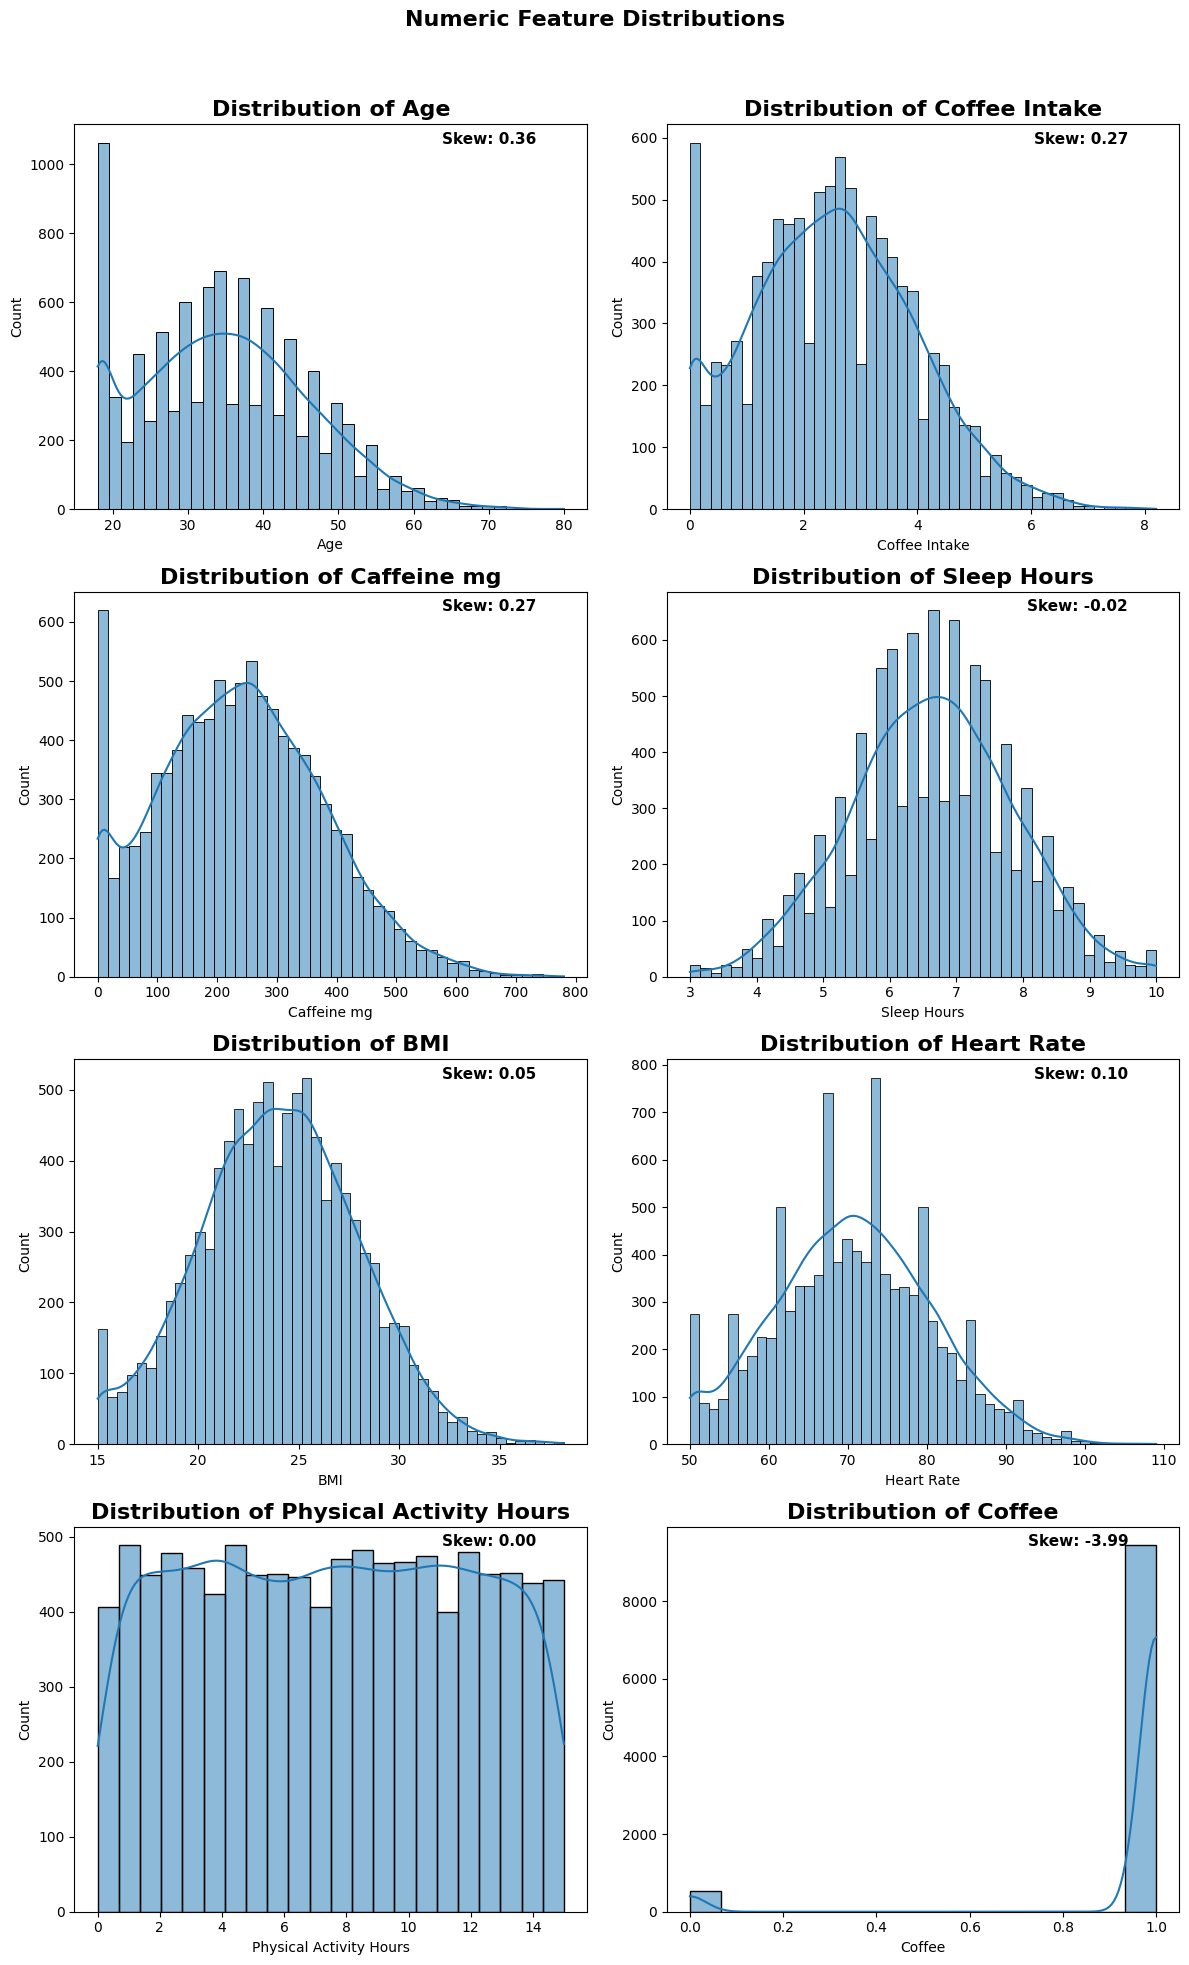

In [23]:
# Numeric features and their distributions
num_figs = plot_feature_grid(df_coffee, numeric_features, plot_hist, suptitle = 'Numeric Feature Distributions')
plt.show()

While the number of physical activity hours has a uniform distribution, the others have relatively normal distribution with a large group of young individuals and those who do not drink coffee.

#### **Categorical Variables**

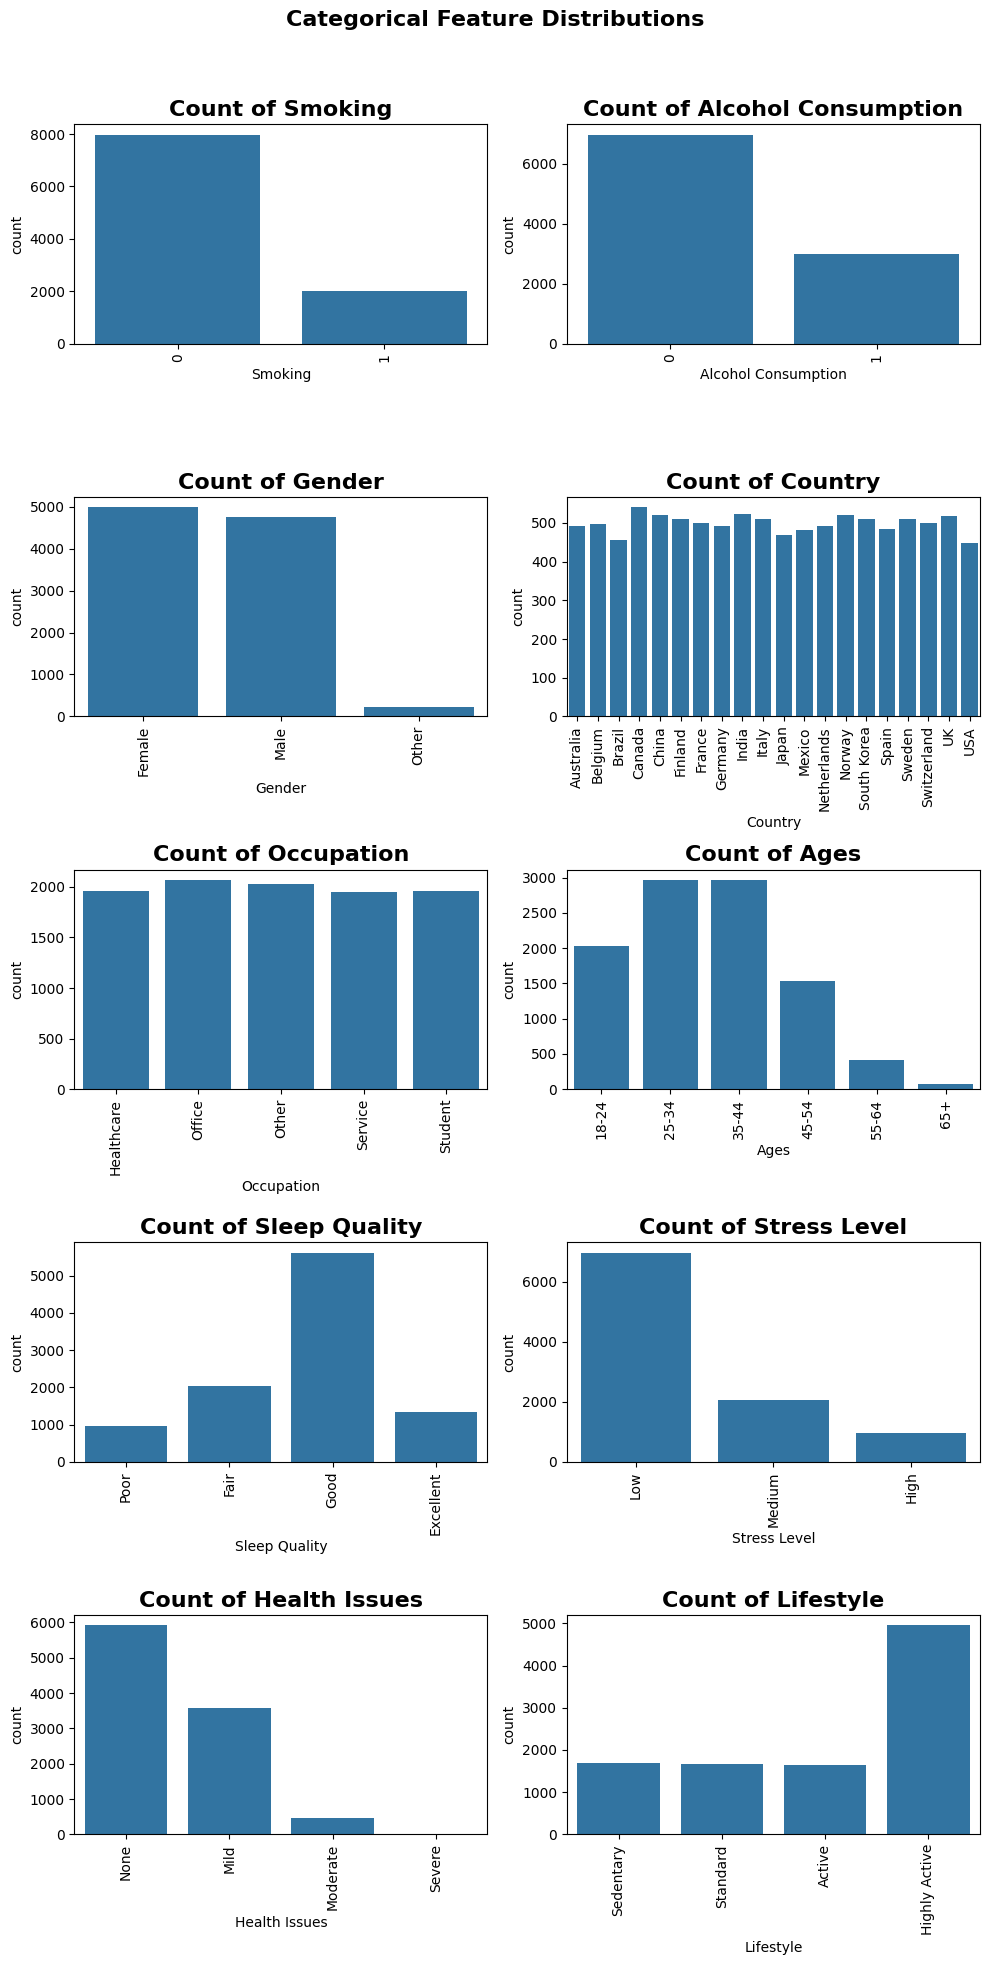

In [24]:
cat_figs = plot_feature_grid(df_coffee, CATEGORICAL_FEAT, plot_count, figsize = (10, 20), suptitle = 'Categorical Feature Distributions')
plt.show()

#### **Derived Features**

##### **Sleep Hours vs Sleep Quality**

Investigating how sleep quality is derived from sleep hours.

In [25]:
sleep_order = df_coffee['Sleep Quality'].cat.categories[::-1]

sleep_stats = (df_coffee.groupby('Sleep Quality', observed = False)['Sleep Hours']
               .describe()
               .reindex(sleep_order))

display(sleep_stats)

,count,mean,std,min,25%,50%,75%,max
Excellent,1345.0,8.593903,0.500439,8.0,8.2,8.5,8.8,10.0
Good,5618.0,6.923514,0.549242,6.0,6.5,6.9,7.4,8.0
Fair,2047.0,5.576698,0.278663,5.0,5.4,5.6,5.8,6.0
Poor,960.0,4.452396,0.456324,3.0,4.2,4.6,4.8,5.0


In [26]:
# Cross table of of Sleep Hours binned and Sleep Quality

sleep_bins = [sleep_stats['min'].min()-1] + sleep_stats['max'][::-1].tolist()

sleep_hour_groups = pd.cut(df_coffee['Sleep Hours'],
                           bins = sleep_bins)

display(Markdown(f'## Sleep Hours Binned vs Sleep Quality'))
display(pd.crosstab(df_coffee['Sleep Quality'], sleep_hour_groups).reindex(sleep_order))

## Sleep Hours Binned vs Sleep Quality

Sleep Hours,"(2.0, 5.0]","(5.0, 6.0]","(6.0, 8.0]","(8.0, 10.0]"
Excellent,0,0,84,1261
Good,0,141,5477,0
Fair,58,1989,0,0
Poor,960,0,0,0


There is a small proportion of individuals who could fall in either two successive categories, since the the maximum of one sleep quality group is the minimum of another. However, those who sleep more than 8 hours always have excellent sleep and those who sleep less than 5 hours have poor sleep.

##### **Coffee Intake vs Caffeine in mg**
Investigate how closely related coffee intake is to caffeine mg.

In [27]:
# Statistical summary of caffeine (mg) values for 1 cup of coffee
df_coffee.loc[df_coffee['Coffee Intake'] == 1, 'Caffeine mg'].describe()

,Caffeine mg
count,170.000000
mean,95.006471
std,2.751141
min,90.300000
25%,92.600000
50%,95.250000
75%,97.300000
max,99.700000


For 1 cup of coffee, caffeine ranges from 90.3 to 99.7 mg with a mean of 95 mg.

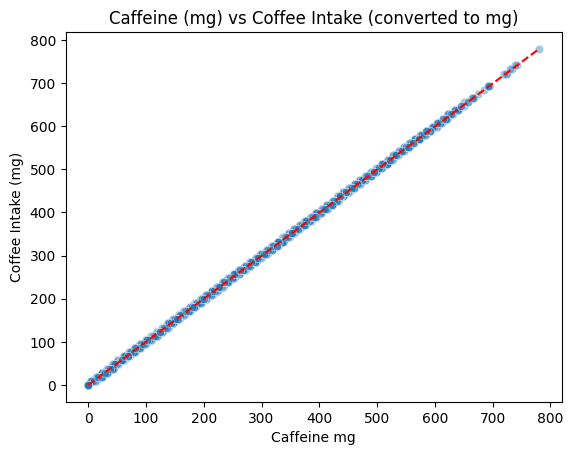

In [28]:
# Caffeine mg vs Coffee Intake * 95 (per documentation)
coffee_mg = df_coffee['Coffee Intake'] * 95

sns.scatterplot(data = df_coffee, x = 'Caffeine mg', y = coffee_mg, alpha = 0.4)

plt.plot([0, df_coffee['Caffeine mg'].max()],
         [0, coffee_mg.max()],
         color = 'red', linestyle = '--', label = 'Alignment')

plt.ylabel('Coffee Intake (mg)')
plt.title('Caffeine (mg) vs Coffee Intake (converted to mg)')
plt.show()

In [29]:
print(f'Correlation between Caffeine mg and Coffee Intake (converted to mg): {df_coffee['Caffeine mg'].corr(coffee_mg).round(4)}')

Correlation between Caffeine mg and Coffee Intake (converted to mg): 0.9998


##### **Health Issues vs Age, BMI, & Sleep Quality**

Health issues is derived from Age, BMI, and Sleep. Investigate how closely these health issures relates to these variables.

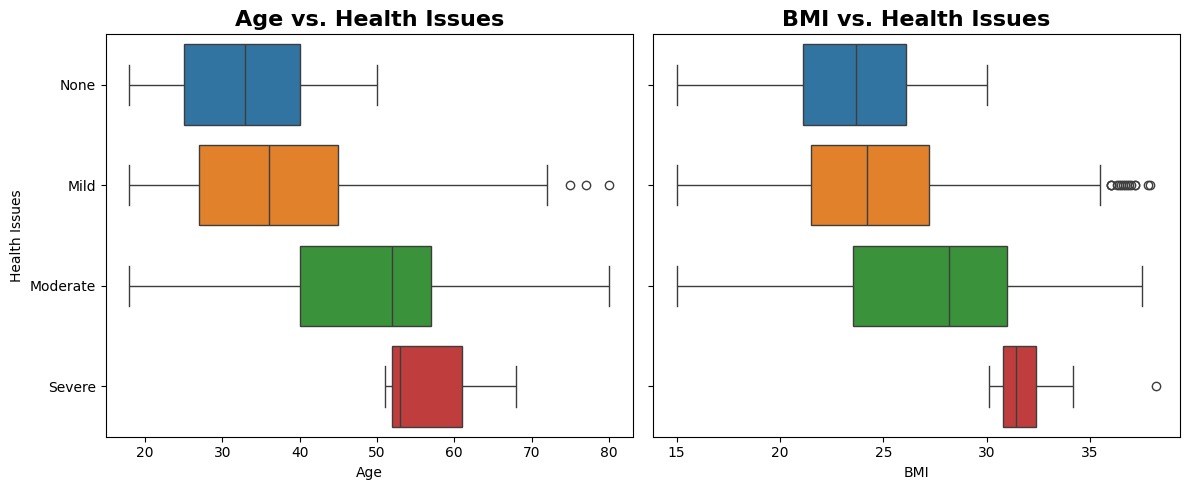

In [30]:
# Age and BMI vs Health Issues
age_health_fig = plot_feature_grid(data = df_coffee, features = ['Age', 'BMI'], plot_func = plot_box,
                                   target = 'Health Issues', figsize = (12, 5),
                                   subplot_kwargs = {'sharey': True}, plot_kwargs = {'hue': 'Health Issues'})
plt.show()

Age appears to increase across increasing severity of health issues with the median age rising from none category to severe category. Additionally, the none group is concentrated in the early 20s-40s, whereas the moderate and severe groups shift toward older ages.

BMI shows a similar pattern with the distributions shifting toward higher BMI values among individuals with moderate to severe health issues.

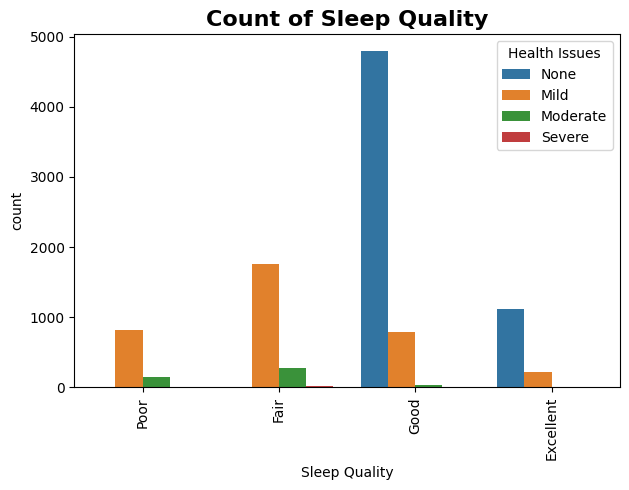

In [31]:
# Sleep Quality vs Health Issues
sq_fig = plot_feature_grid(data = df_coffee, features = ['Sleep Quality'], plot_func = plot_count,
                           target = 'Health Issues', figsize = (12, 5), plot_kwargs = {'hue': 'Health Issues'})

plt.show()

In [32]:
# Cross Table of Sleep Quality vs Health Issues
display(Markdown(f'## Sleep Quality across Health Issues'))
display(pd.crosstab(df_coffee['Sleep Quality'], df_coffee['Health Issues']).reindex(sleep_order))

## Sleep Quality across Health Issues

Health Issues,None,Mild,Moderate,Severe
Excellent,1123,216,6,0
Good,4794,789,35,0
Fair,0,1755,278,14
Poor,0,813,144,3


Individuals with no health issues either have good or excellent sleep while those with severe issues have poor or fair sleep.

##### **Correlation**

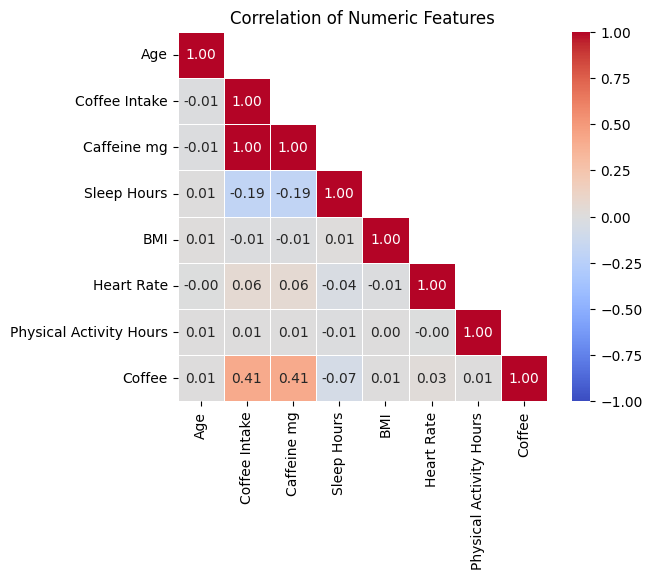

In [33]:
# Correlation of numeric features
num_corr = df_coffee[numeric_features].corr()
corr_mask = np.triu(np.ones_like(num_corr, dtype = bool), k = 1)

sns.heatmap(num_corr, mask = corr_mask,
            annot = True, fmt = '.2f',
            cmap = 'coolwarm',
            vmin = -1, vmax = 1,
            square = True, linewidths = 0.4)

plt.title('Correlation of Numeric Features')
plt.show()

With the exception of the direct correlation between coffee intake and caffeine (mg), there are weak correlations between the numeric features.  There is weak negative correlation between the number of hours of sleep and coffee consumption (-0.19), where the more coffee is consumed there is a weak association to less sleep.

### **Sleep Quality**

Sleep quality is the feature of interest, and this section explores the differences in sleep quality groups with different features in the dataset.

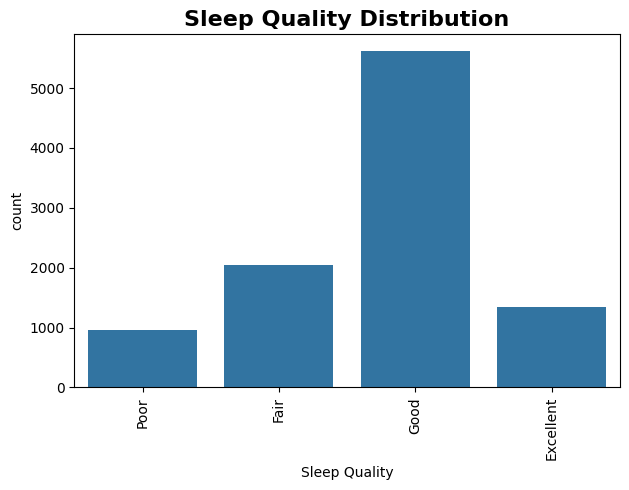

,proportion
Sleep Quality,
Good,0.563490
Fair,0.205316
Excellent,0.134905
Poor,0.096289


In [34]:
sq_dist = plot_feature_grid(df_coffee, ['Sleep Quality'], plot_count, figsize = (12,5), title = 'Sleep Quality Distribution')
plt.show()

df_coffee['Sleep Quality'].value_counts(normalize = True, dropna = False)

56.4% of individuals have good to excellent sleep.  

#### **Sleep & Stress**

Per the data dictionary, stress levels are engineered with sleep and lifestyle features in mind.

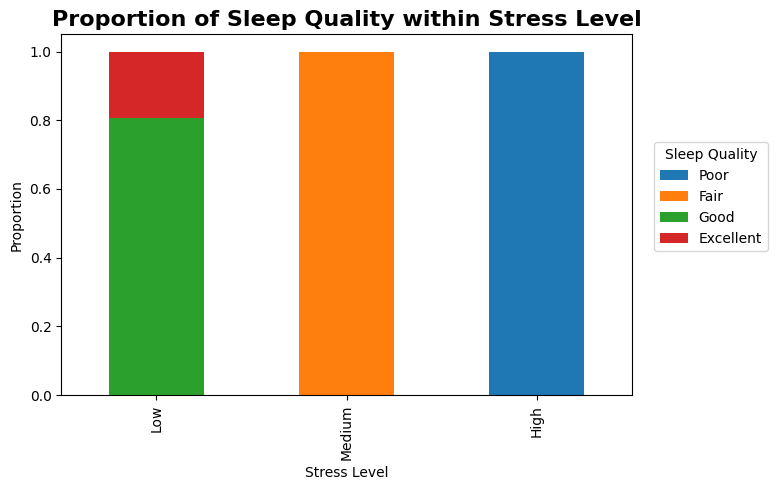

## Sleep Quality across Stress Levels

Sleep Quality,Poor,Fair,Good,Excellent
Stress Level,,,,
Low,0,0,5618,1345
Medium,0,2047,0,0
High,960,0,0,0


In [35]:
sleep_stress = categorical_eda(data = df_coffee, feature = 'Stress Level', target = 'Sleep Quality',
                               title = 'Proportion of Sleep Quality within Stress Level')
plt.show()

display(Markdown(f'## Sleep Quality across Stress Levels'))
display(pd.crosstab(df_coffee['Stress Level'], df_coffee['Sleep Quality']))

The stacked bar graph and cross table show that there is a deterministic rule to determine how sleep quality groups are classified within stress levels. Individuals with low stress either of good or excellent sleep, medium stress only fair sleep, and only high stressed individuals have poor sleep.

#### **Sleep Quality & Health Issues**

Per the data dictionary, sleep variables partially contributed to the engineered variable, Health Issues.

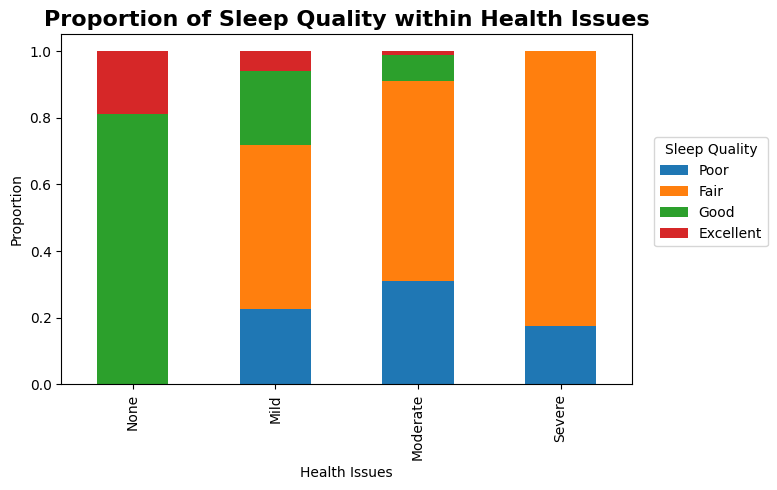

## Sleep Quality across Health Issues

Health Issues,None,Mild,Moderate,Severe
Excellent,1123,216,6,0
Good,4794,789,35,0
Fair,0,1755,278,14
Poor,0,813,144,3


In [36]:
# Sleep Quality vs Health Issues
sq_health = categorical_eda(data = df_coffee, feature = 'Health Issues', target = 'Sleep Quality')
plt.show()

# Cross Table of Sleep Quality vs Health Issues
display(Markdown(f'## Sleep Quality across Health Issues'))
display(pd.crosstab(df_coffee['Sleep Quality'], df_coffee['Health Issues']).reindex(sleep_order))

Individuals with no health issues either have good or excellent sleep while those with severe issues have poor or fair sleep.

#### **Numeric Pairplots**

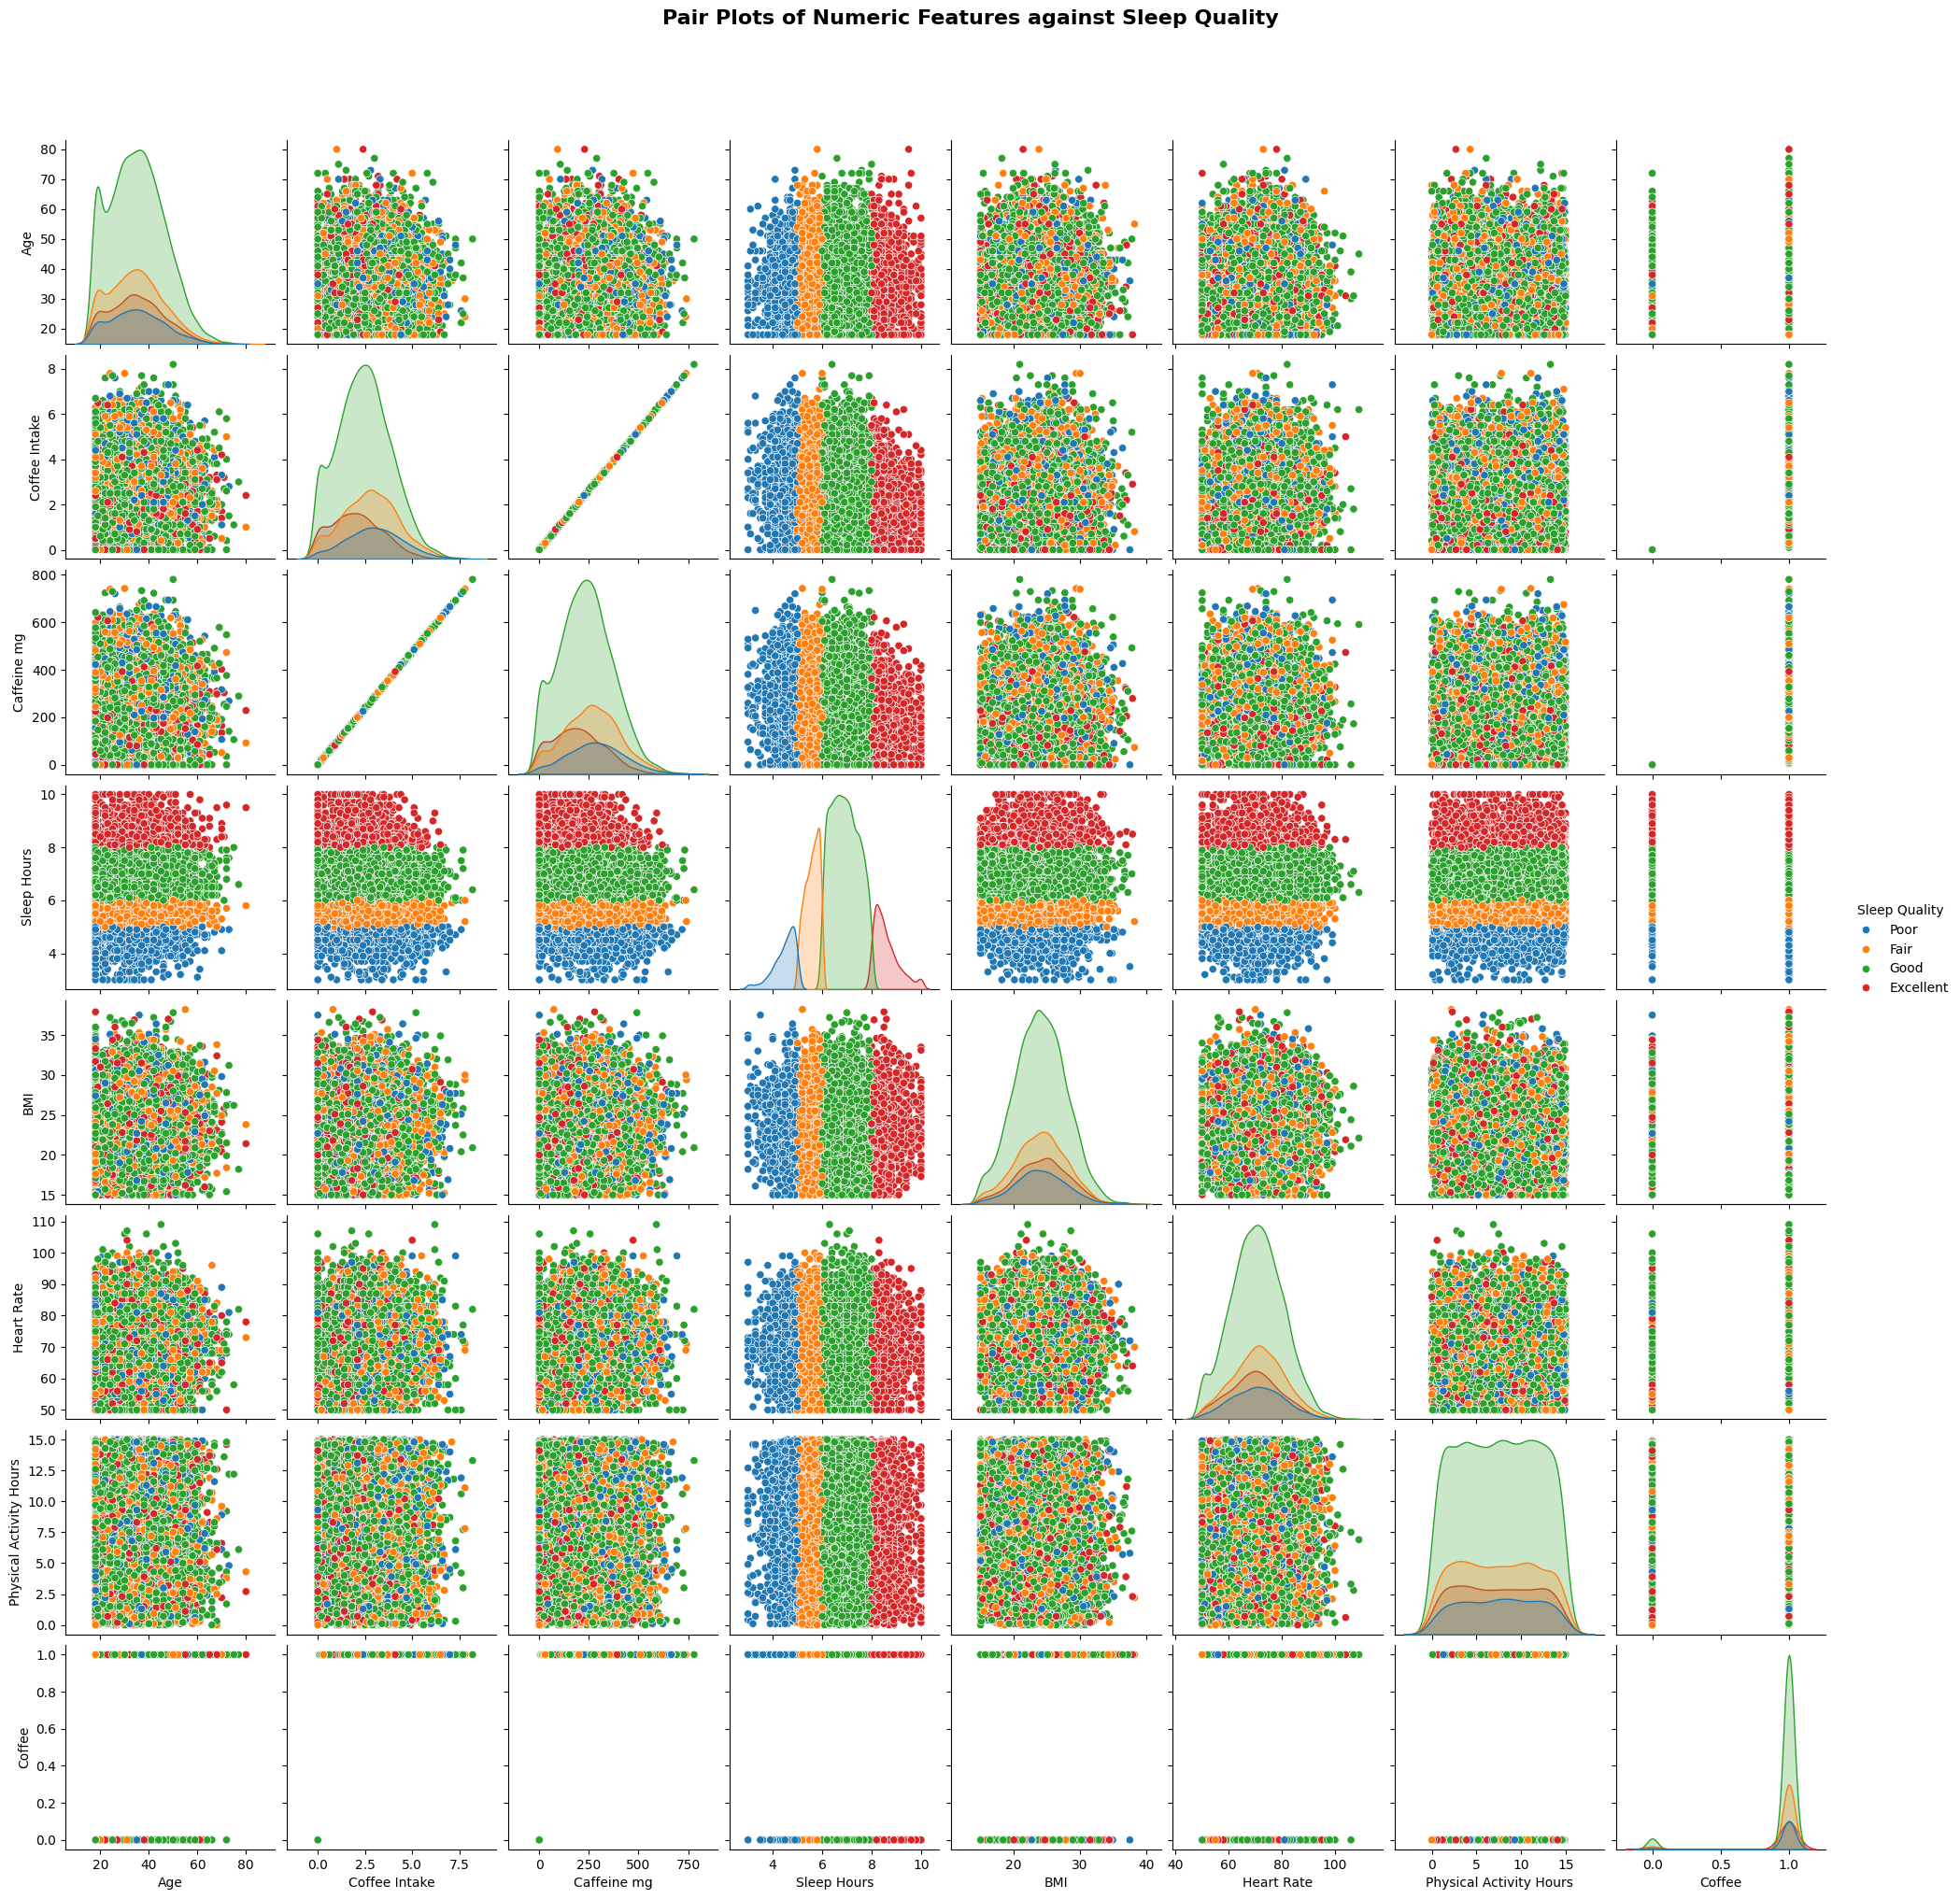

In [37]:
sleep_pairplot = sns.pairplot(data = df_coffee, vars = numeric_features, hue = 'Sleep Quality')
sleep_pairplot.fig.subplots_adjust(top = 0.95)
sleep_pairplot.fig.suptitle('Pair Plots of Numeric Features against Sleep Quality',
                            y = 1.02, fontsize = 16, fontweight = 'bold')
plt.show()

The pairplot results support the initial findings on the strong correlation between coffee intake and caffeine (mg) as well as sleep hours (binned) and sleep quality.

#### **Sleep Quality and Demographics & Health Characteristics**
*Note: Engineered features such as stress levels and health issues are not included in this section as they were mentioned above.

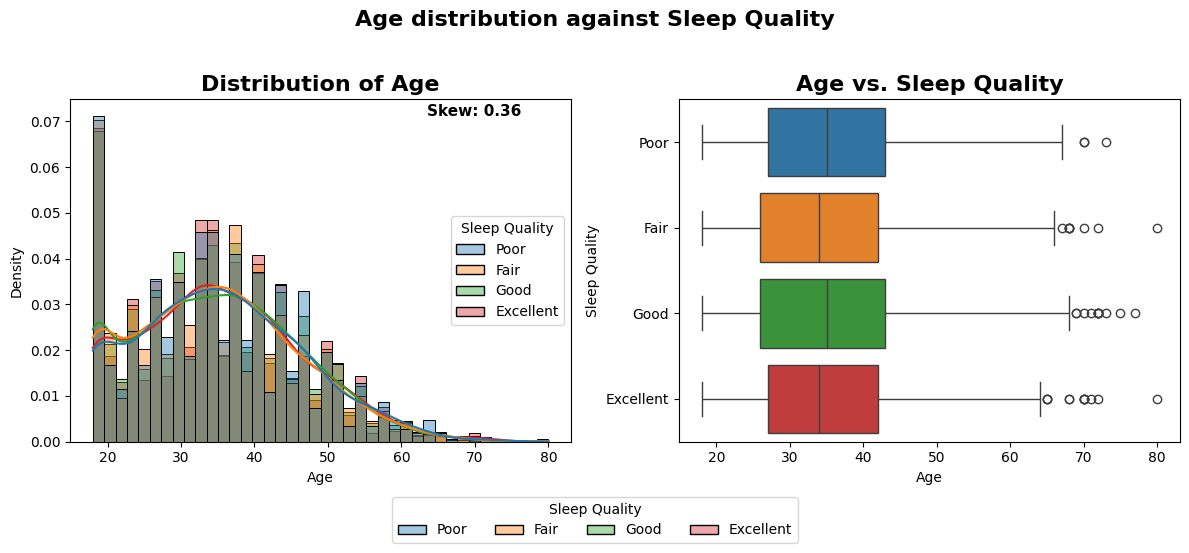

,Feature Type,Test Name,Effect Size/Correlation,p-value
Age,int64,Spearman,0.0069 (Spearman ρ),0.4904


____________________________________________________________________________________________________


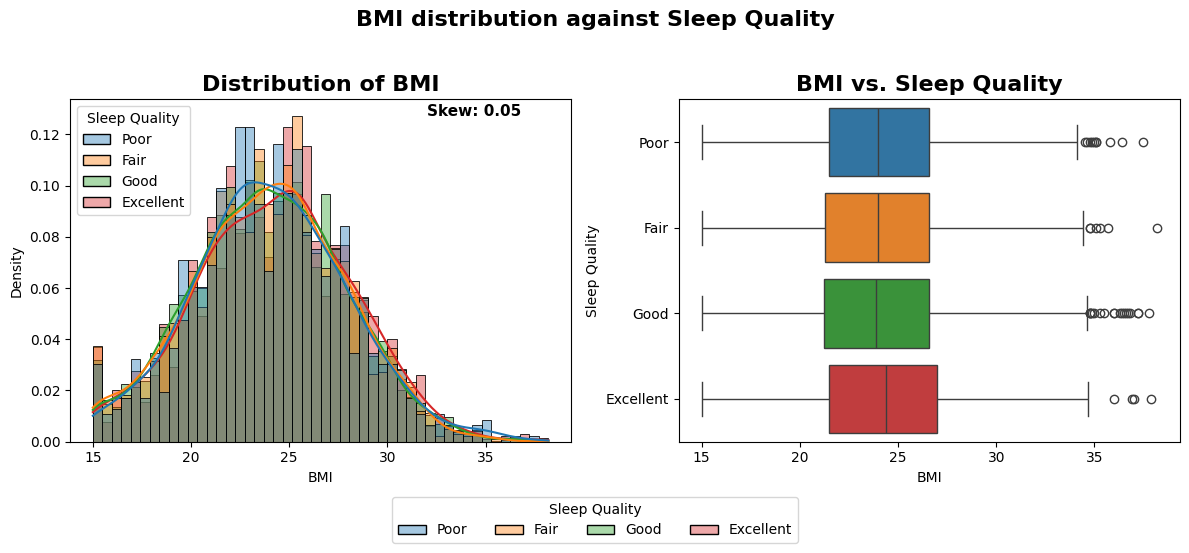

,Feature Type,Test Name,Effect Size/Correlation,p-value
BMI,float64,Spearman,0.0119 (Spearman ρ),0.2358


____________________________________________________________________________________________________


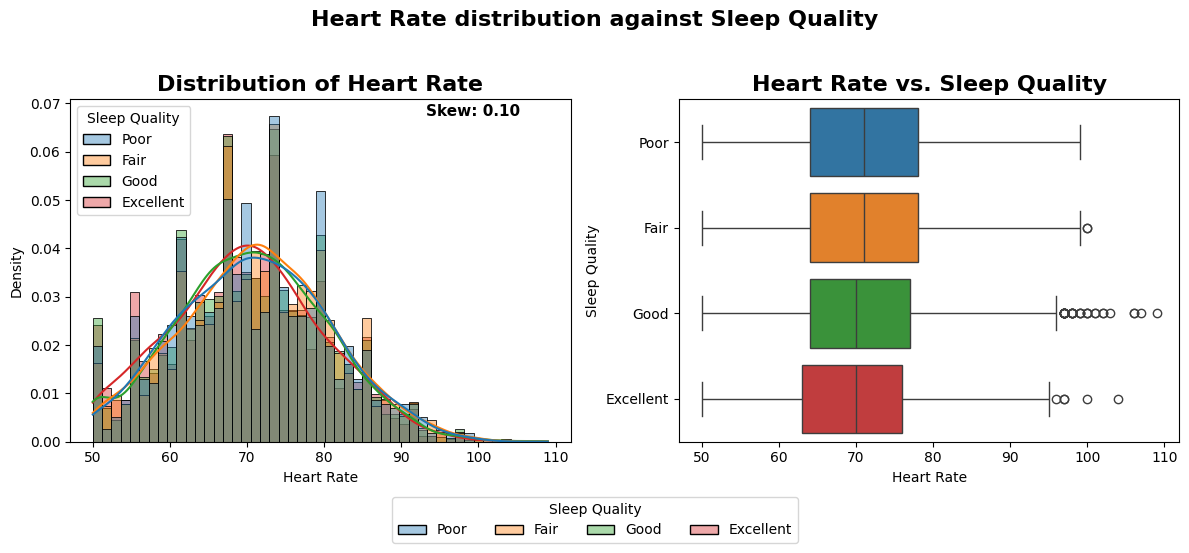

,Feature Type,Test Name,Effect Size/Correlation,p-value
Heart Rate,int64,Spearman,-0.0377 (Spearman ρ),0.0002


____________________________________________________________________________________________________


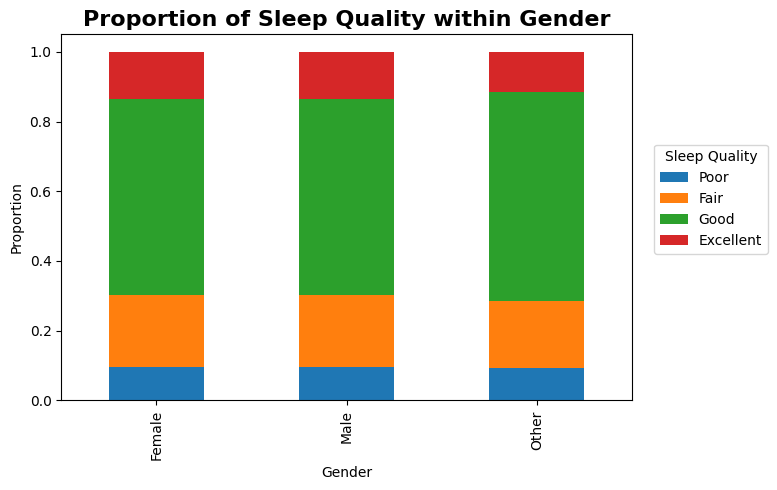

,Feature Type,Test Name,Test Statistic,p-value,Effect Size/Correlation
Gender,category,Chi-Square,1.4643,0.9618,0.0086 (Cramer's V)


____________________________________________________________________________________________________


In [38]:
# Demographics & Health visualizations and statistical tests
dh_results = features_interest(
    data = df_coffee,
    features = DEMO_HEALTH_FEAT,
    target = 'Sleep Quality',
    nominal_features = NOMINAL_FEAT,
    show_legend = True,
    hist_kwargs = HIST_KWARGS,
    box_kwargs = BOX_KWARGS
)

for result in dh_results:

    display(result['Figure'])
    display(result['Stats'])

    plt.close(result['Figure'])

    print('_' * 100)

In [39]:
# Demographics and health results
dh_stats = pd.concat(result['Stats'] for result in dh_results).sort_values(['p-value', 'Test Name'])
display(Markdown(f'## Statistical Associations between Demographics & Health Characteristics with Sleep Quality'))
display(dh_stats)

## Statistical Associations between Demographics & Health Characteristics with Sleep Quality

,Feature Type,Test Name,Effect Size/Correlation,p-value,Test Statistic
Heart Rate,int64,Spearman,-0.0377 (Spearman ρ),0.0002,NaN
BMI,float64,Spearman,0.0119 (Spearman ρ),0.2358,NaN
Age,int64,Spearman,0.0069 (Spearman ρ),0.4904,NaN
Gender,category,Chi-Square,0.0086 (Cramer's V),0.9618,1.4643


Statistical testing identified a weak negative relationship between heart rate and sleep quality (ρ = -0.038, p < 0.01) where the lower the heart rate the better the sleep quality.

Otherwise, there are no other meaningful associations between sleep quality and the demographics and health characteristics; Age and BMI rate showed near-zero Spearman correlations with sleep quality (|ρ| < 0.01, p > 0.05).  There was no statistical association between gender and sleep quality (chi-square = 1.46, p > 0.05, and Cramer's V < 0.001 indicates a negligible effect).

#### **Sleep Quality & Lifestyle Characteristics**

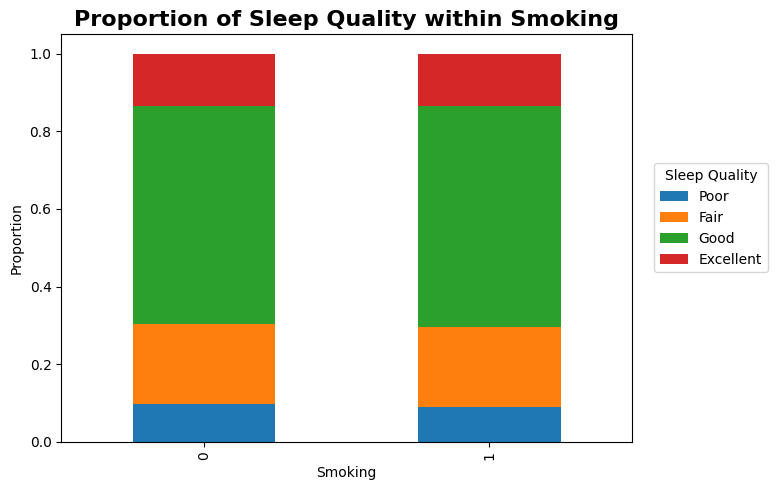

,Feature Type,Test Name,Test Statistic,p-value,Effect Size/Correlation
Smoking,category,Mann-Whitney U,7892304.5000,0.5065,0.0086 (Rank-biserial)


____________________________________________________________________________________________________


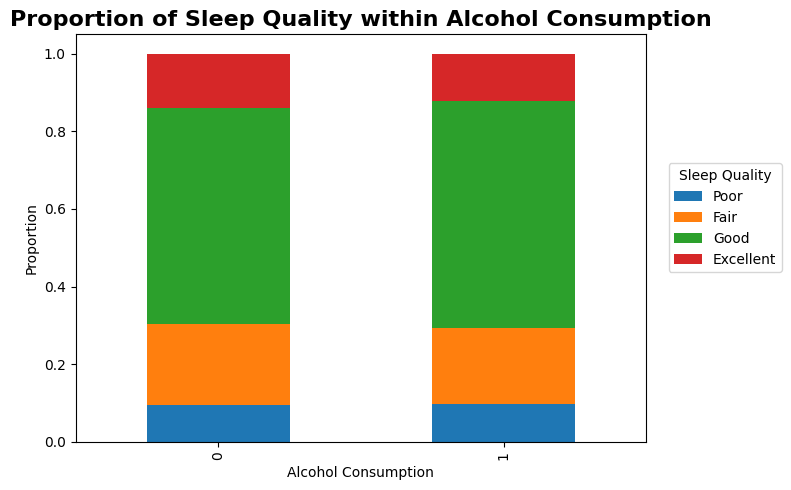

,Feature Type,Test Name,Test Statistic,p-value,Effect Size/Correlation
Alcohol Consumption,category,Mann-Whitney U,10488285.5000,0.7406,-0.0038 (Rank-biserial)


____________________________________________________________________________________________________


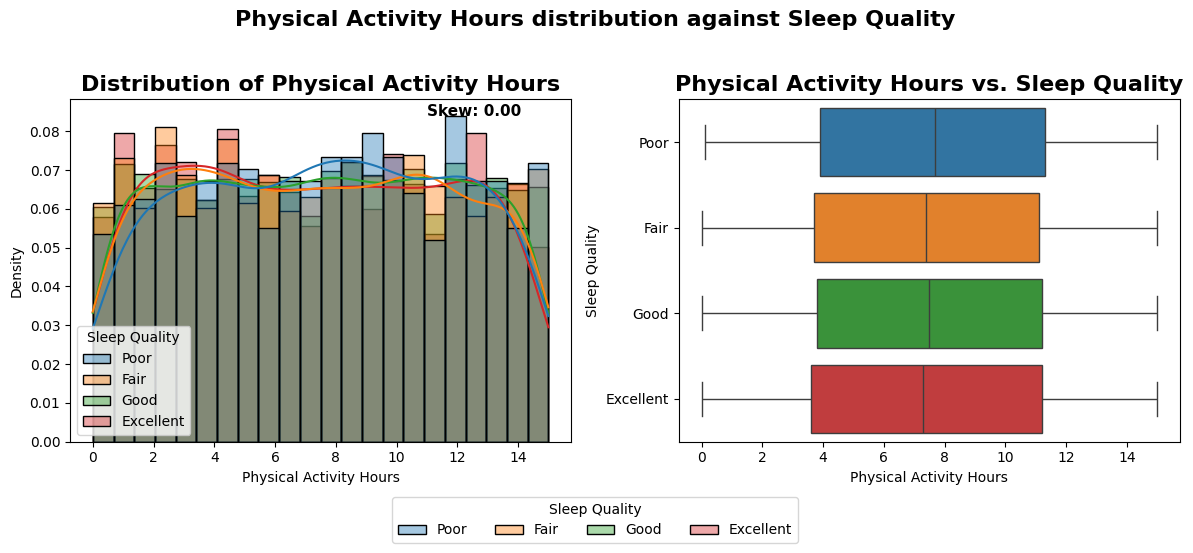

,Feature Type,Test Name,Effect Size/Correlation,p-value
Physical Activity Hours,float64,Spearman,-0.0087 (Spearman ρ),0.3840


____________________________________________________________________________________________________


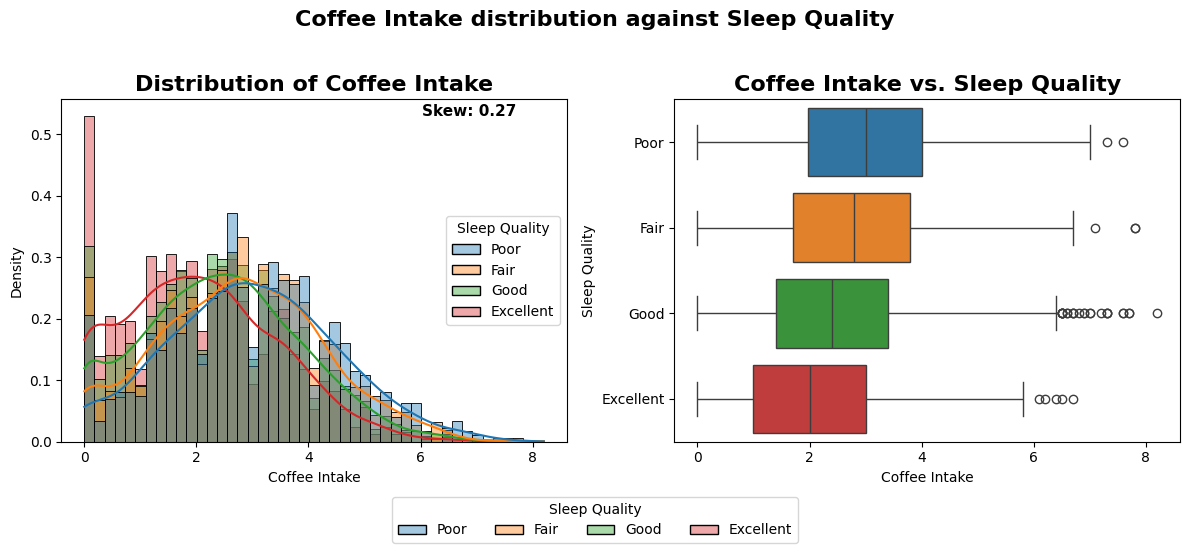

,Feature Type,Test Name,Effect Size/Correlation,p-value
Coffee Intake,float64,Spearman,-0.1724 (Spearman ρ),0.0000


____________________________________________________________________________________________________


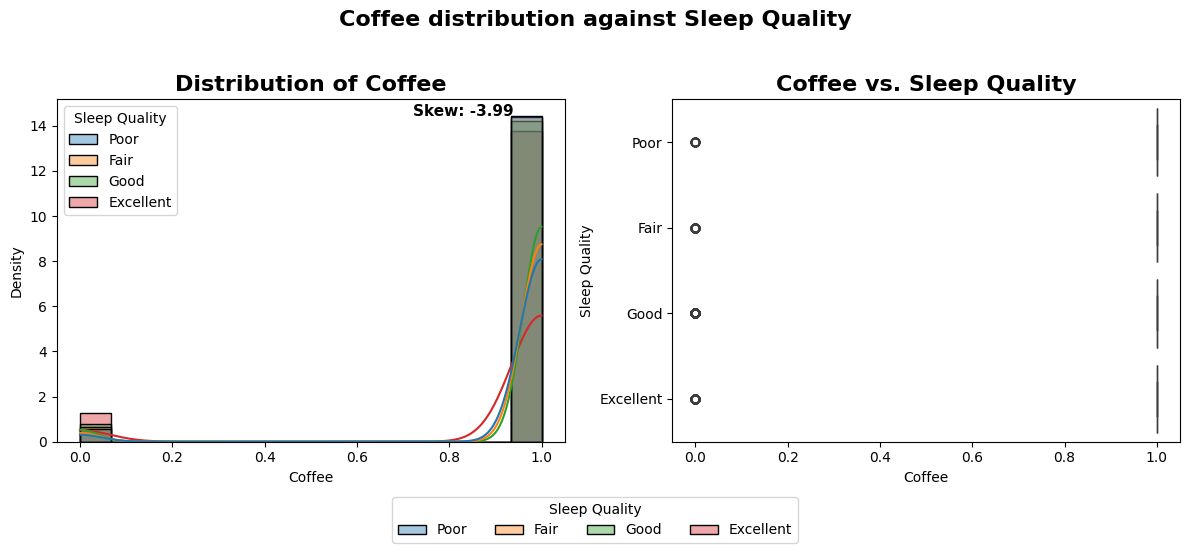

,Feature Type,Test Name,Effect Size/Correlation,p-value
Coffee,int64,Spearman,-0.0540 (Spearman ρ),0.0000


____________________________________________________________________________________________________


In [40]:
# Lifestyle visualizations and statistical tests
l_results = features_interest(
    data = df_coffee,
    features = LIFESTYLE_FEAT,
    target = 'Sleep Quality',
    nominal_features = NOMINAL_FEAT,
    show_legend = True,
    hist_kwargs = HIST_KWARGS,
    box_kwargs = BOX_KWARGS
)

for result in l_results:

    display(result['Figure'])
    display(result['Stats'])

    plt.close(result['Figure'])

    print('_' * 100)

In [41]:
# Lifestyle results
lstats = pd.concat(result['Stats'] for result in l_results).sort_values(['p-value', 'Test Name'])
display(Markdown(f'## Statistical Associations between Lifestyle Characteristics and Sleep Quality'))
display(lstats)


## Statistical Associations between Lifestyle Characteristics and Sleep Quality

,Feature Type,Test Name,Test Statistic,p-value,Effect Size/Correlation
Coffee Intake,float64,Spearman,NaN,0.0000,-0.1724 (Spearman ρ)
Coffee,int64,Spearman,NaN,0.0000,-0.0540 (Spearman ρ)
Physical Activity Hours,float64,Spearman,NaN,0.3840,-0.0087 (Spearman ρ)
Smoking,category,Mann-Whitney U,7892304.5000,0.5065,0.0086 (Rank-biserial)
Alcohol Consumption,category,Mann-Whitney U,10488285.5000,0.7406,-0.0038 (Rank-biserial)


There is a weak negative monotonic relationship between the amount of coffee consumed and sleep quality (ρ = -0.172, p < 0.001), indicating higher coffee intake was associate with poorer sleep quality.

Non-coffee consumers have significantly better sleep than those who consume coffee (U = 2,805,029, p < 0.001). Although the difference is statistically significant, the effect size is weak (rank-biserial correlation = -0.125).

### **Coffee Consumers**
Investigating characteristics of coffee consumers as well as the differences between coffee and non-coffee consumers.

#### **How Common is Coffee Consumption?**

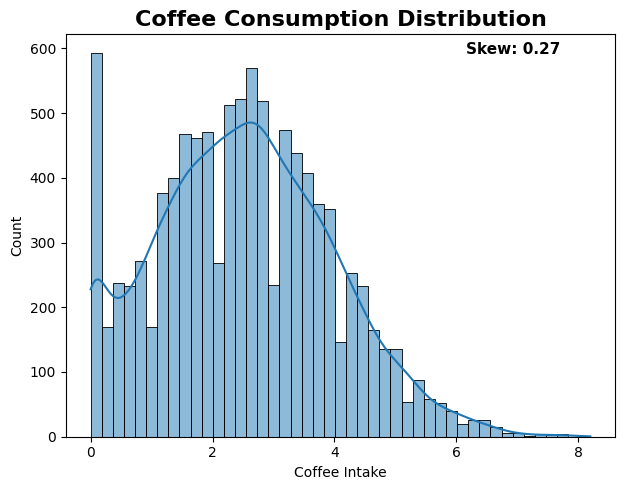

In [42]:
coffee_dist = plot_feature_grid(df_coffee, ['Coffee Intake'], plot_hist, figsize = (12,5), title = 'Coffee Consumption Distribution')
plt.show()

In [43]:
df_coffee['Coffee'].value_counts(normalize = True)

,proportion
Coffee,
1,0.947041
0,0.052959


94.7% individuals drink coffee while 5.3% do not.

#### **Meet the Coffee Drinkers** *Who drinks coffee?*

In [44]:
# Coffee drinkers
coffee_drinkers = df_coffee[df_coffee['Coffee'] == 1]

# No caffeine at all
non_coffee_drinkers = df_coffee[(df_coffee['Coffee'] == 0) & (df_coffee['Caffeine mg'] == 0.0)]

print(f'Total number of coffee drinkers: {coffee_drinkers.shape[0]}')
print(f'Total number of non-coffee drinkers: {non_coffee_drinkers.shape[0]}')

Total number of coffee drinkers: 9442
Total number of non-coffee drinkers: 528


In [45]:
coffee_drinkers.describe()

,Age,Coffee Intake,Caffeine mg,Sleep Hours,BMI,Heart Rate,Physical Activity Hours,Coffee
count,9442.000000,9442.000000,9442.000000,9442.000000,9442.000000,9442.000000,9442.000000,9442.0
mean,34.966427,2.657520,252.493148,6.615537,23.994408,70.690638,7.490023,1.0
std,11.147861,1.354032,128.615457,1.216724,3.917259,9.822184,4.315029,0.0
min,18.000000,0.100000,4.900000,3.000000,15.000000,50.000000,0.000000,1.0
25%,26.000000,1.600000,155.700000,5.800000,21.300000,64.000000,3.800000,1.0
50%,35.000000,2.600000,246.200000,6.600000,24.000000,71.000000,7.500000,1.0
75%,43.000000,3.600000,338.500000,7.400000,26.700000,77.000000,11.200000,1.0
max,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.000000,1.0


In [46]:
non_coffee_drinkers.describe()

,Age,Coffee Intake,Caffeine mg,Sleep Hours,BMI,Heart Rate,Physical Activity Hours,Coffee
count,528.000000,528.0,528.0,528.000000,528.000000,528.000000,528.000000,528.0
mean,34.659091,0.0,0.0,6.971591,23.864394,69.409091,7.391477,0.0
std,11.416776,0.0,0.0,1.265716,3.744033,9.666904,4.342551,0.0
min,18.000000,0.0,0.0,3.000000,15.000000,50.000000,0.000000,0.0
25%,26.000000,0.0,0.0,6.100000,21.400000,62.750000,3.700000,0.0
50%,34.000000,0.0,0.0,7.000000,23.950000,70.000000,7.400000,0.0
75%,42.000000,0.0,0.0,7.900000,26.400000,75.000000,11.050000,0.0
max,72.000000,0.0,0.0,10.000000,37.500000,106.000000,14.900000,0.0


Based on the descriptive statistics, there is a difference in means of the sleep hours of coffee consumers and those who do no (6.62 vs 6.97 hours).

In [47]:
coffee_drinkers.describe(include = 'category')

,Gender,Country,Sleep Quality,Stress Level,Health Issues,Occupation,Smoking,Alcohol Consumption,Ages,Lifestyle
count,9442,9442,9442,9442,9442,9442,9442,9442,9442,9442
unique,3,20,4,3,4,5,2,2,6,4
top,Female,Canada,Good,Low,None,Office,0,0,35-44,Highly Active
freq,4717,506,5323,6556,5568,1963,7536,6620,2823,4692


In [48]:
non_coffee_drinkers.describe(include = 'category')

,Gender,Country,Sleep Quality,Stress Level,Health Issues,Occupation,Smoking,Alcohol Consumption,Ages,Lifestyle
count,528,528,528,528,528,528,528,528,528,528
unique,3,20,4,3,4,5,2,2,6,4
top,Female,Canada,Good,Low,None,Healthcare,0,0,25-34,Highly Active
freq,266,34,295,407,349,113,437,353,158,259


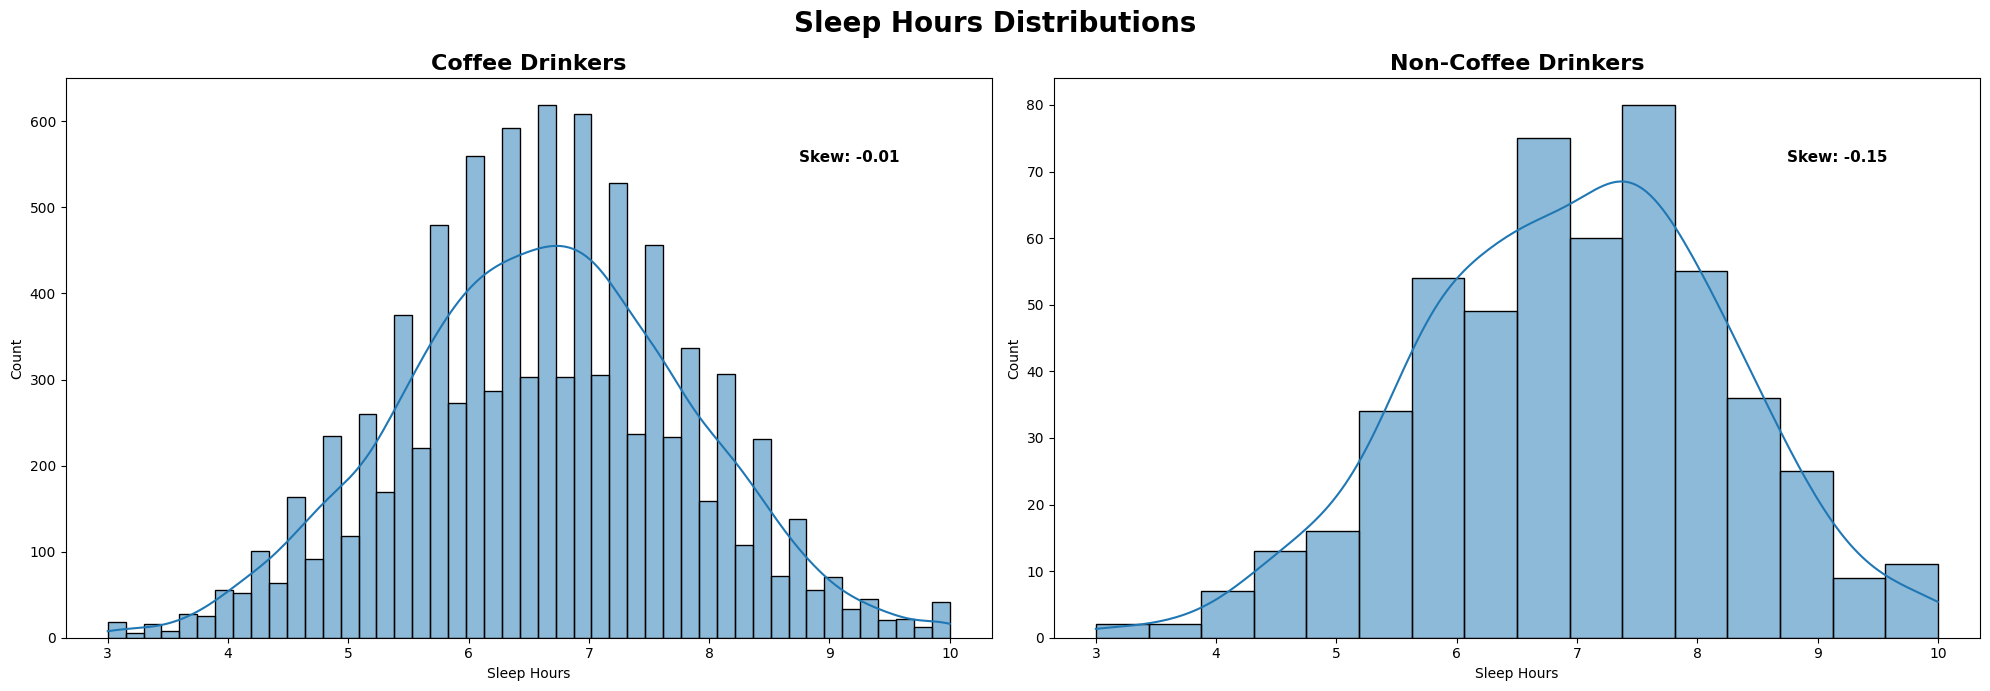

In [49]:
fig_sleep = compare_2_distributions(
    data1 = coffee_drinkers,
    data2 = non_coffee_drinkers,
    feature = 'Sleep Hours',
    label1 = 'Coffee Drinkers',
    label2 = 'Non-Coffee Drinkers',
    suptitle = 'Sleep Hours Distributions'
)

plt.show()

In [50]:
t_results = compare_cont_features(coffee_drinkers, non_coffee_drinkers, feature = 'Sleep Hours',
                                  center = 'mean', alternative = 'less')
display(t_results)

,Levene p-value,Equal variance,T-statistic,T-test p-value
Sleep Hours,0.1351,True,-6.5296,0.0


The coffee drinkers averaged 6.62 hours of sleep compared to 6.97 hours among non-coffee drinkers. An independent-samples t-test indicated that coffee drinkers had significantly lower mean sleep duration (t = -6.53, p < 0.01).

In [51]:
coffee_drinkers.describe(include = 'category')

,Gender,Country,Sleep Quality,Stress Level,Health Issues,Occupation,Smoking,Alcohol Consumption,Ages,Lifestyle
count,9442,9442,9442,9442,9442,9442,9442,9442,9442,9442
unique,3,20,4,3,4,5,2,2,6,4
top,Female,Canada,Good,Low,None,Office,0,0,35-44,Highly Active
freq,4717,506,5323,6556,5568,1963,7536,6620,2823,4692


In [52]:
non_coffee_drinkers.describe(include = 'category')

,Gender,Country,Sleep Quality,Stress Level,Health Issues,Occupation,Smoking,Alcohol Consumption,Ages,Lifestyle
count,528,528,528,528,528,528,528,528,528,528
unique,3,20,4,3,4,5,2,2,6,4
top,Female,Canada,Good,Low,None,Healthcare,0,0,25-34,Highly Active
freq,266,34,295,407,349,113,437,353,158,259


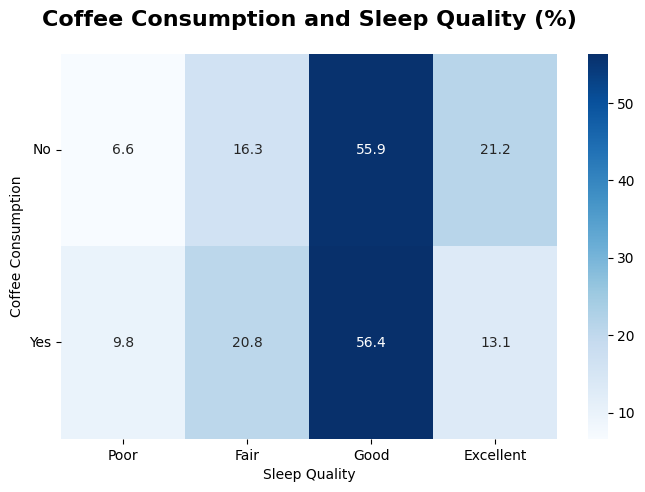

In [53]:
coffee_sleepq_fig = plot_crosstab_heatmap(df_coffee, 'Coffee', 'Sleep Quality',
                                          ylabel = 'Coffee Consumption', row_labels = ['No', 'Yes'],
                                          title = 'Coffee Consumption and Sleep Quality (%)',
                                          cmap = 'Blues')
plt.show()

In [54]:
chi2, p, dof, expected, cramers_v = cramer_v(data = df_coffee, feature = 'Coffee', target = 'Sleep Quality')
coffee_sleep_chi = {'Feature Type': 'category',
                    'Test Name': 'Chi-Square',
                    'Chi-square statistic': round(chi2, 4),
                    'Chi-square p-value': round(p, 4),
                    'Degrees of Freedom': dof,
                    'Cramer\'s V': round(cramers_v, 4)}
coffee_sleep_chi_df = pd.DataFrame(coffee_sleep_chi, index = ['Coffee'])
display(coffee_sleep_chi_df)

,Feature Type,Test Name,Chi-square statistic,Chi-square p-value,Degrees of Freedom,Cramer's V
Coffee,category,Chi-Square,34.7653,0.0,3,0.0591


In [55]:
residuals = stand_residuals(data = df_coffee, feature = 'Coffee', target = 'Sleep Quality', expected = expected)

display(Markdown(f'### Coffee vs Sleep Quality Standardized Residuals'))
display(residuals)

### Coffee vs Sleep Quality Standardized Residuals

Sleep Quality,Poor,Fair,Good,Excellent
Coffee,,,,
0,-2.221593,-2.152048,-0.146269,4.830738
1,0.525351,0.508905,0.034589,-1.142348


There are substantially more excellent sleep observations than expected under the assumption of independence between coffee consumption and sleep quality as seen with the large standardized residual among non-coffee consumers with excellent sleep quality (r = 4.83).  There are less poor and fair sleep quality observations than expected under the assumption of independence between coffee consumption and sleep quality among non-coffee consumers (r = -2.22 and r = -2.15, respectively).

#### **How Much Coffee Do They Drink?**

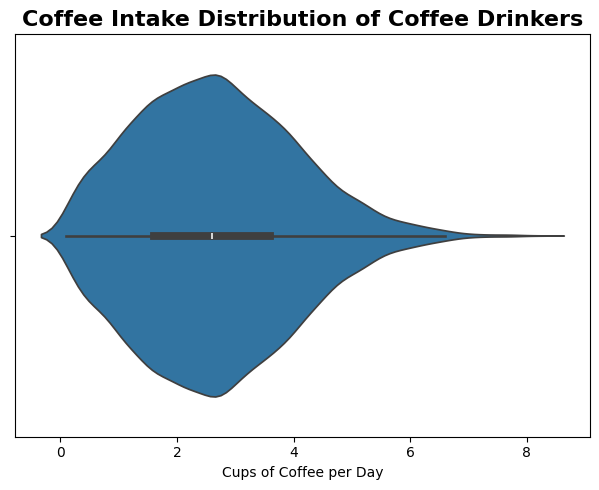

In [56]:
coffee_violin = plot_feature_grid(coffee_drinkers, ['Coffee Intake'], plot_violin, figsize = (12,5), title = 'Coffee Intake Distribution of Coffee Drinkers')
coffee_violin.axes[0].set_xlabel('Cups of Coffee per Day')
plt.show()

The median cups of coffee consumed per day by coffee drinkers is between 2-3 cups.

#### **Who Drinks the Most Coffee?**

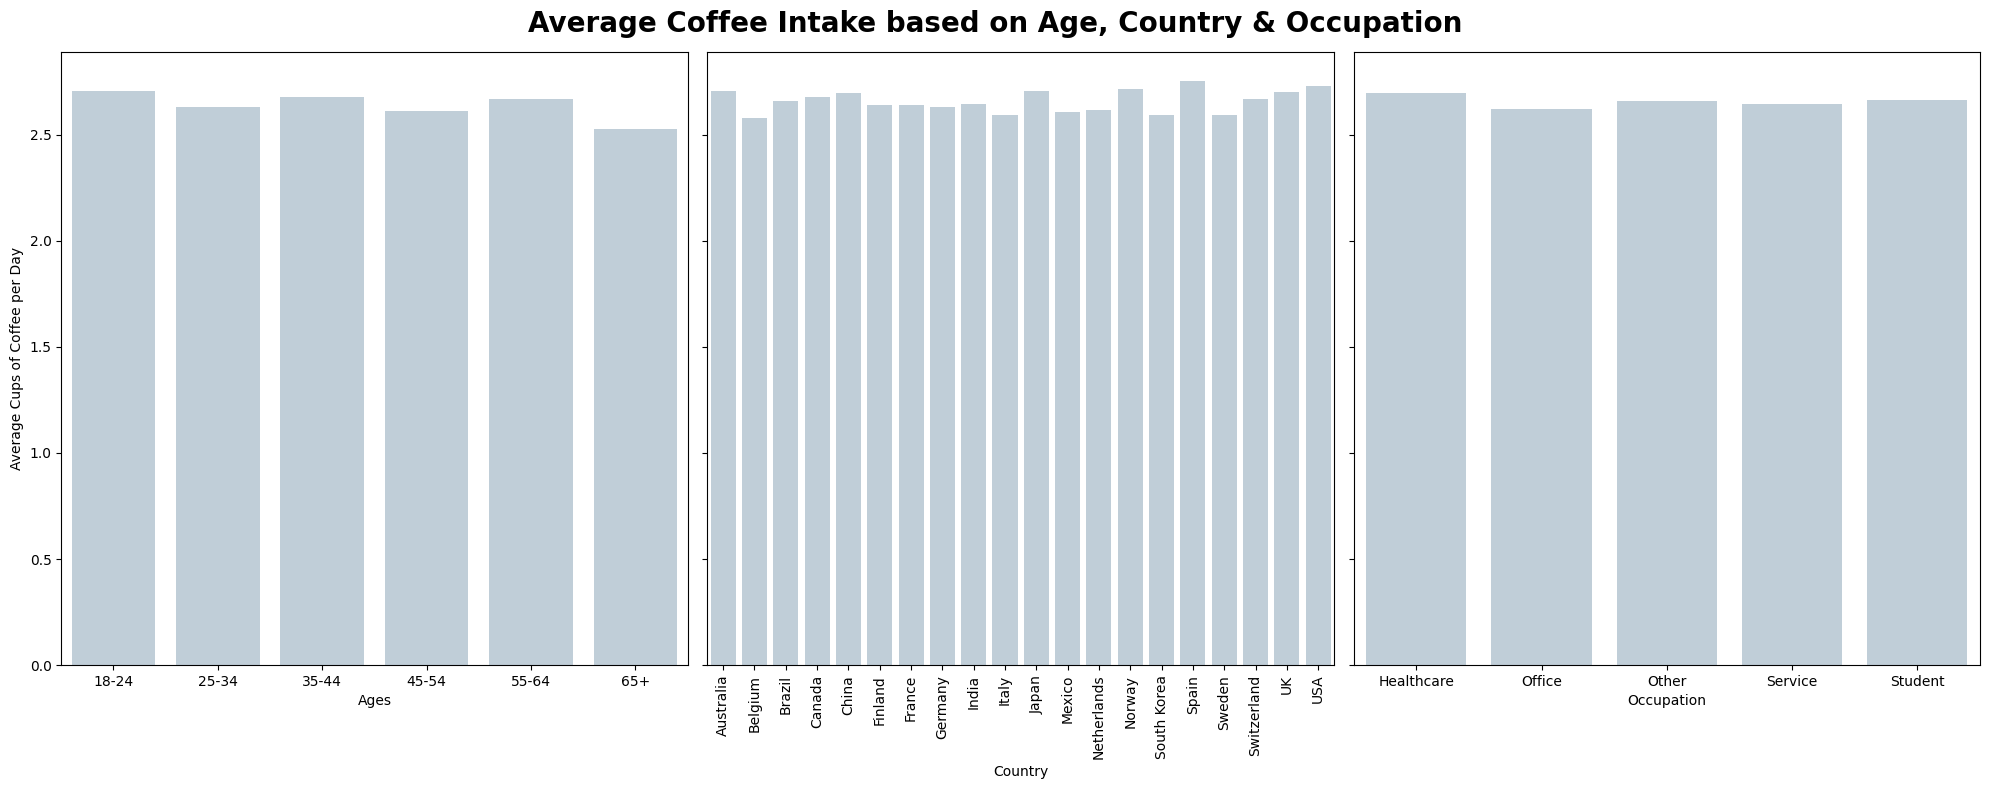

In [57]:
fig, axes = plt.subplots(1, 3, figsize = (20,8), sharex = False, sharey = True)

age_coffee = plot_mean(coffee_drinkers, feature = 'Ages', target = 'Coffee Intake', ax = axes[0],
                       ylabel = 'Average Cups of Coffee per Day', color = '#BCCEDC')
country_coffee = plot_mean(coffee_drinkers, feature = 'Country', target = 'Coffee Intake', ax = axes[1],
                           rotation = 90, color = '#BCCEDC')
occ_coffee = plot_mean(coffee_drinkers, feature = 'Occupation', target = 'Coffee Intake', ax = axes[2], color = '#BCCEDC')

fig.suptitle('Average Coffee Intake based on Age, Country & Occupation', fontsize = 20, fontweight = 'bold')

fig.tight_layout()
plt.show()


Coffee consumers drink on average between 2.5-3 cups of coffee per day across age, country, and occupation.

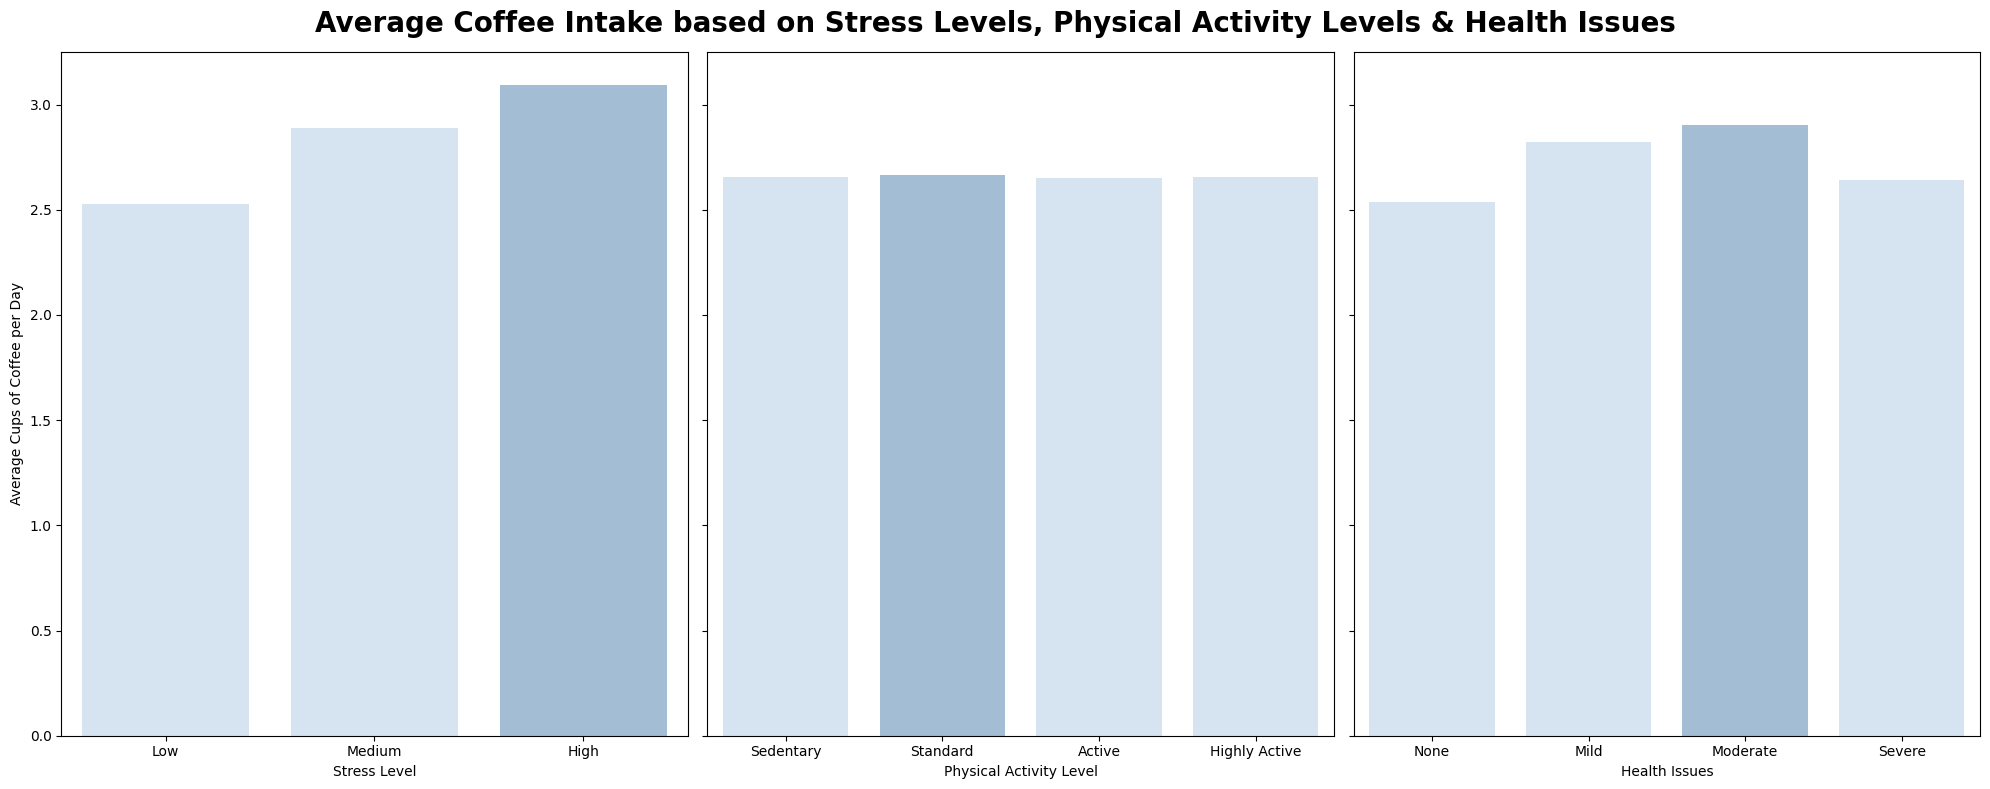

In [58]:
fig, axes = plt.subplots(1, 3, figsize = (20,8), sharex = False, sharey = True)

stress_coffee = plot_mean_highlight(coffee_drinkers, feature = 'Stress Level', target = 'Coffee Intake',
                                    ax = axes[0], ylabel = 'Average Cups of Coffee per Day')
phys_hours_coffee = plot_mean_highlight(coffee_drinkers, feature = 'Lifestyle', target = 'Coffee Intake',
                                        ax = axes[1], xlabel = 'Physical Activity Level')
health_coffee = plot_mean_highlight(coffee_drinkers, feature = 'Health Issues', target = 'Coffee Intake', ax = axes[2])

fig.suptitle('Average Coffee Intake based on Stress Levels, Physical Activity Levels & Health Issues', fontsize = 20, fontweight = 'bold')
fig.tight_layout()
plt.show()

In [59]:
coffee_drinkers['Health Issues'].dtype

CategoricalDtype(categories=['None', 'Mild', 'Moderate', 'Severe'], ordered=True, categories_dtype=object)

In [60]:
display(Markdown(f'### Coffee Intake & Stress Level'))
eda_test(coffee_drinkers, feature = 'Coffee Intake', target = 'Stress Level')

### Coffee Intake & Stress Level

,Feature Type,Test Name,Effect Size/Correlation,p-value
Coffee Intake,float64,Spearman,0.1475 (Spearman ρ),0.0000


There is an increasing average number of cups of coffee consumed as stress levels increase from approximately 2.5 cups of coffee with low stress levels to 3 cups of coffee consumed daily with high stress levels. This is statistically significant but the monotic association is weak between the amount of coffee consumed and stress levels (Spearman's ρ = 0.147, p < 0.001).

The average coffee consumption does not appear to be associated with physical activity levels. While those who have mild and moderate seem to have slightly higher average consumption than those who do not have health issues or those with severe health issues. These findings are from the visualizations alone and are meant to be descriptive and exploratory.

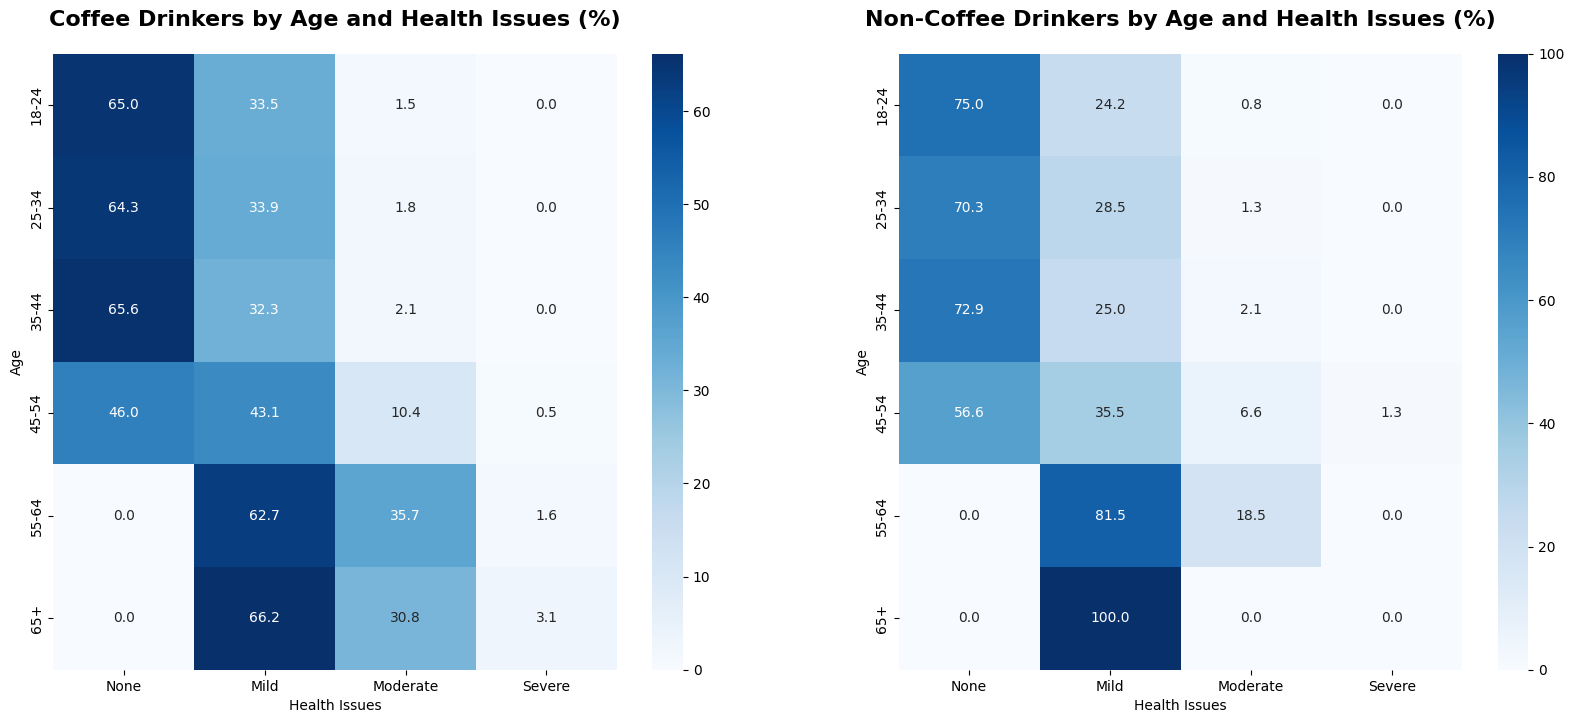

In [61]:
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

coffee_agehealth_fig = plot_crosstab_heatmap(coffee_drinkers, 'Ages', 'Health Issues',
                                             ylabel = 'Age',
                                             title = 'Coffee Drinkers by Age and Health Issues (%)',
                                             cmap = 'Blues', ax = axes[0])
ncoffee_agehealth_fig = plot_crosstab_heatmap(non_coffee_drinkers, 'Ages', 'Health Issues',
                                             ylabel = 'Age',
                                             title = 'Non-Coffee Drinkers by Age and Health Issues (%)',
                                             cmap = 'Blues', ax = axes[1])

plt.show()

In [62]:
prop = pd.crosstab(non_coffee_drinkers['Ages'], non_coffee_drinkers['Health Issues'])
display(Markdown(f'### Non-coffee consumers\' Age & Health Issues'))
display(prop)

### Non-coffee consumers' Age & Health Issues

Health Issues,None,Mild,Moderate,Severe
Ages,,,,
18-24,90,29,1,0
25-34,111,45,2,0
35-44,105,36,3,0
45-54,43,27,5,1
55-64,0,22,5,0
65+,0,3,0,0


The heatmaps with age brackets compared with respective health issues suggest an age-related pattern. Among coffee consumers, the percentage with no health issues decreased across age brackets while moderate and severe health issues became more prevalent.  It appears that non-coffee consumers have a less pronounced increase in severity of health issues with age, yet the data is sparse to even support a reliable comparison.

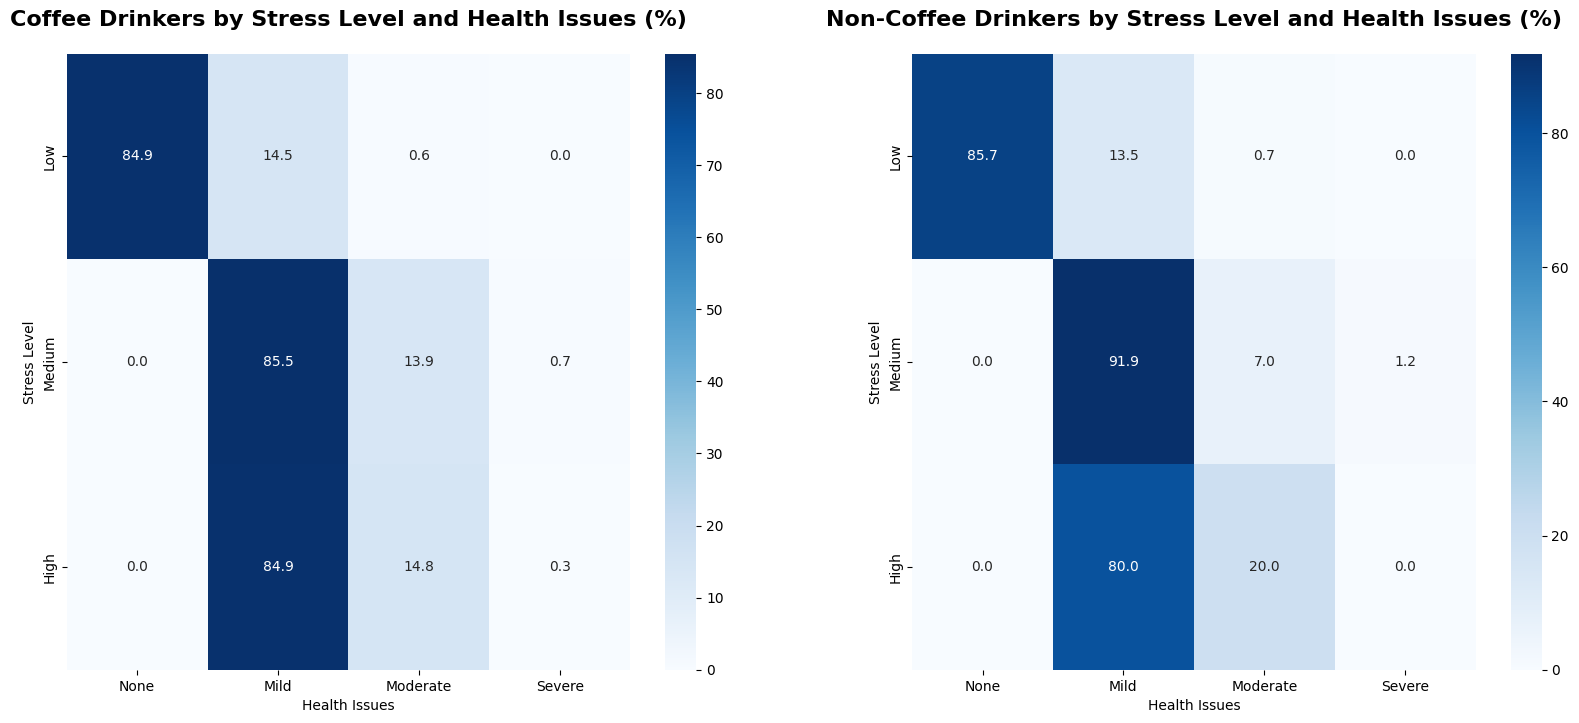

In [63]:
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

coffee_stresshealth_fig = plot_crosstab_heatmap(coffee_drinkers, 'Stress Level', 'Health Issues',
                                             title = 'Coffee Drinkers by Stress Level and Health Issues (%)',
                                             cmap = 'Blues', ax = axes[0])
ncoffee_stresshealth_fig = plot_crosstab_heatmap(non_coffee_drinkers, 'Stress Level', 'Health Issues',
                                             title = 'Non-Coffee Drinkers by Stress Level and Health Issues (%)',
                                             cmap = 'Blues', ax = axes[1])

plt.show()

In [64]:
prop_sh = pd.crosstab(non_coffee_drinkers['Stress Level'], non_coffee_drinkers['Health Issues'])
display(Markdown(f'### Non-coffee consumers\' Stress Level & Health Issues'))
display(prop_sh)

### Non-coffee consumers' Stress Level & Health Issues

Health Issues,None,Mild,Moderate,Severe
Stress Level,,,,
Low,349,55,3,0
Medium,0,79,6,1
High,0,28,7,0


The heatmaps with stress levels compared with respective health issues suggest a stress-related pattern regardless of whether or not individuals consumed coffee where those with low stress levels are more likely to have no health issues, while those with higher stress levels ar emore likely to have mild to moderate health issues. While it seems that non-coffee consumers with medium stress levels have a higher percentage of mild health issues instead of moderate health issues compared to their counterparts who do consume coffee, the data is too sparse to even support a reliable comparison.

#### **Does Coffee Affect Sleep?**

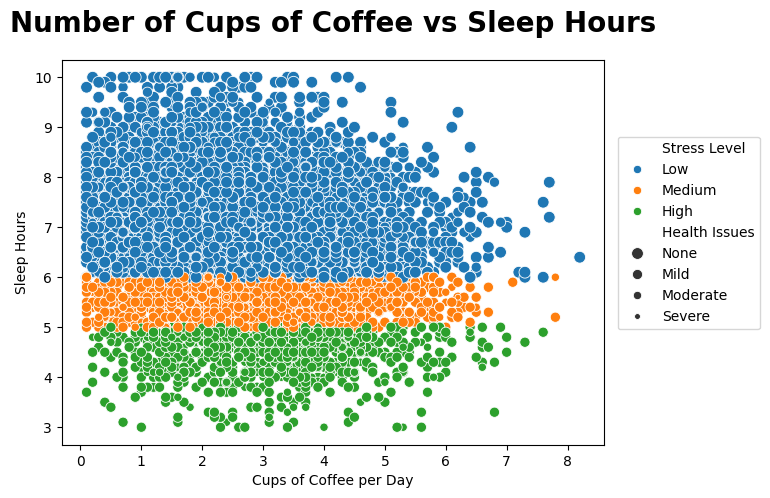

In [65]:
coffee_sleeph_fig = plot_relationship(coffee_drinkers, feature = 'Coffee Intake', target = 'Sleep Hours',
                                      title = 'Number of Cups of Coffee vs Sleep Hours',
                                      xlabel = 'Cups of Coffee per Day',
                                      hue = 'Stress Level', size = 'Health Issues')
plt.show()

The scatterplot is highly discriminatory of sleep hours and stress levels no matter how many cups of coffee are consumed.   While individuals with lower stress levels sleep longer even with a wider range of cups of coffee consumed, those with medium stress sleep between 5-6 hours per night and those with a high stress level sleep 3-5 hours per night. The relationship between number of hours of sleep per night and stress levels is not surprising as the stress level variable was engineered from sleep-related variables per the data dictionary.

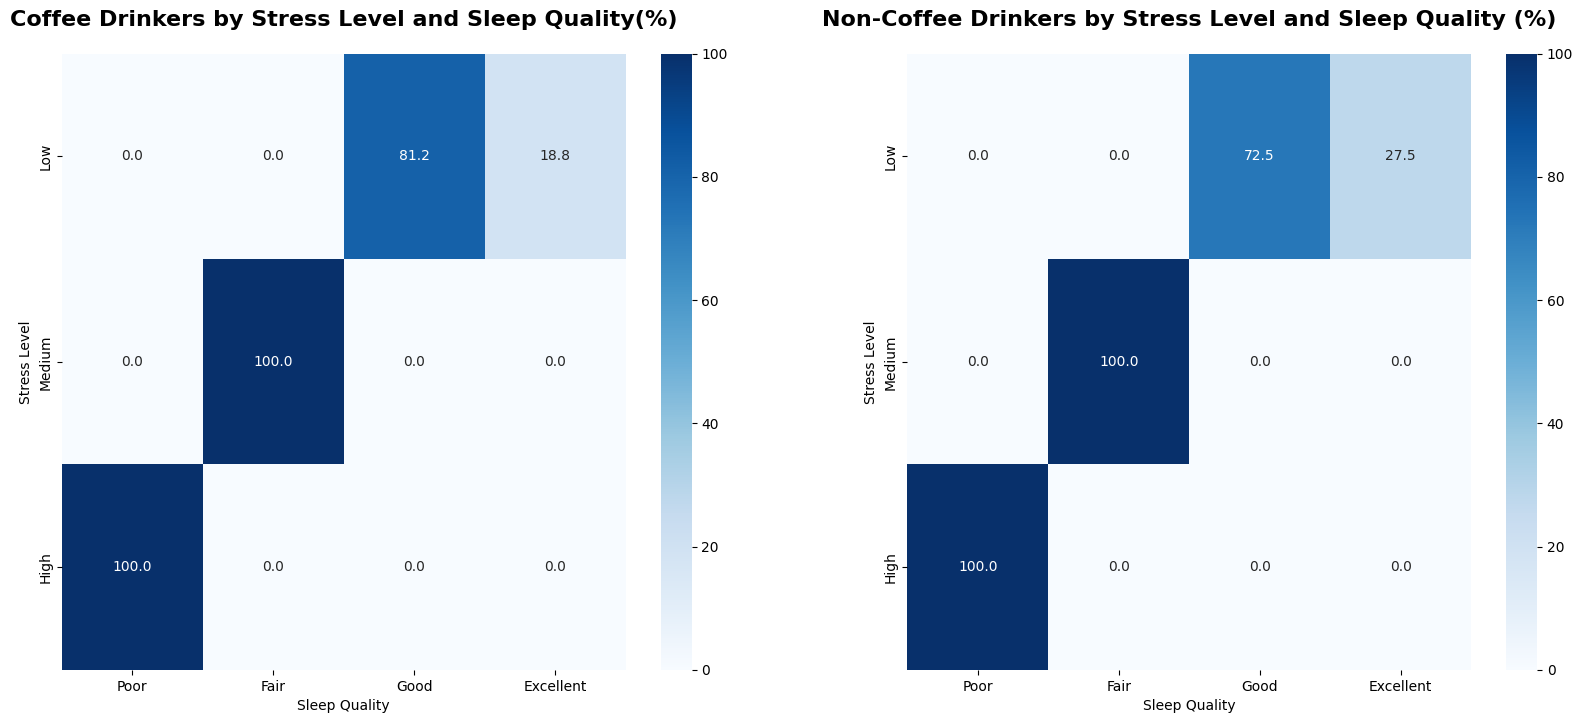

In [66]:
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

coffee_stresss_fig = plot_crosstab_heatmap(coffee_drinkers, 'Stress Level', 'Sleep Quality',
                                           title = 'Coffee Drinkers by Stress Level and Sleep Quality(%)',
                                           cmap = 'Blues', ax = axes[0])
ncoffee_stress_fig = plot_crosstab_heatmap(non_coffee_drinkers, 'Stress Level', 'Sleep Quality',
                                           title = 'Non-Coffee Drinkers by Stress Level and Sleep Quality (%)',
                                           cmap = 'Blues', ax = axes[1])

plt.show()

In [67]:
display(Markdown(f'### Coffee Consumers\' Stress Level and Sleep Quality'))
display(pd.crosstab(coffee_drinkers['Stress Level'], coffee_drinkers['Sleep Quality']))

### Coffee Consumers' Stress Level and Sleep Quality

Sleep Quality,Poor,Fair,Good,Excellent
Stress Level,,,,
Low,0,0,5323,1233
Medium,0,1961,0,0
High,925,0,0,0


In [68]:
prop_ss = pd.crosstab(non_coffee_drinkers['Stress Level'], non_coffee_drinkers['Sleep Quality'])
display(Markdown(f'### Non-coffee consumers\' Stress Level & Sleep Quality'))
display(prop_ss)

### Non-coffee consumers' Stress Level & Sleep Quality

Sleep Quality,Poor,Fair,Good,Excellent
Stress Level,,,,
Low,0,0,295,112
Medium,0,86,0,0
High,35,0,0,0


Among individuals classified as having low stress, 81.2% of coffee consumers experience good sleep quality while 18.8% experience excellent sleep, compared with 72.5% and 27.5%, respectively, among non-cofffee consumers. Individuals with medium stress experience fair sleep while those with high stress levels experience poor sleep quality in both groups. Since stress levels is derived from sleep-related variables, these patterns are interpreted descriptively rather than as evidence of a statistical finding.